In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#F8F9FA",
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "axes.labelsize"    : 11,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
})

TEAM_COLORS = {
    "MI"  : "#004BA0", "CSK" : "#F9CD05", "RCB" : "#EC1C24",
    "KKR" : "#3A225D", "SRH" : "#FF822A", "RR"  : "#254AA5",
    "GT"  : "#1C1C1C", "LSG" : "#A4262C", "DC"  : "#0078BC",
    "PBKS": "#AA4545"
}

In [12]:
bbb  = pd.read_csv(r"C:\Users\saket\AppData\Local\Programs\Microsoft VS Code\cleaned_bbb.csv")
mat  = pd.read_csv(r"C:\Users\saket\AppData\Local\Programs\Microsoft VS Code\cleaned_matches.csv")
bat  = pd.read_csv(r"C:\Users\saket\AppData\Local\Programs\Microsoft VS Code\cleaned_batters.csv")
bowl = pd.read_csv(r"C:\Users\saket\AppData\Local\Programs\Microsoft VS Code\cleaned_bowlers.csv")
ar   = pd.read_csv(r"C:\Users\saket\AppData\Local\Programs\Microsoft VS Code\cleaned_allrounders.csv")
vn   = pd.read_csv(r"C:\Users\saket\AppData\Local\Programs\Microsoft VS Code\cleaned_venue.csv")

mat_res = mat[mat["no_result"] == 0].copy()
mat_res["toss_winner_won"] = (mat_res["toss_winner"] == mat_res["winner"]).astype(int)

print("Datasets loaded:")
for name, df in [("bbb",bbb),("matches",mat),("venue",vn),
                  ("bat",bat),("bowl",bowl),("ar",ar)]:
    print(f"  {name:} {df.shape}")

Datasets loaded:
  bbb (17285, 34)
  matches (74, 31)
  venue (17, 10)
  bat (55, 22)
  bowl (61, 21)
  ar (46, 32)


In [13]:
total_runs  = bbb["total_runs"].sum()
total_wkts  = bbb["bowler_wicket"].sum()
total_balls = bbb["is_legal"].sum()
total_mat   = bbb["match_id"].nunique()
avg_inn     = bbb.groupby(["match_id","innings"])["total_runs"].sum().mean()
overall_rr  = total_runs / total_balls * 6
print(f"\n--- IPL 2025 Overview ---")
print(f"  Total matches          : {total_mat}")
print(f"  Total runs scored      : {total_runs:,}")
print(f"  Total wickets fallen   : {total_wkts}")
print(f"  Overall run rate       : {overall_rr:.2f}")
print(f"  Average innings score  : {avg_inn:.1f}")
print(f"\n--- Batting Summary (describe) ---")
print(bat[["RUNS","AVG","SR","Price_Cr"]].describe().round(2))
print(f"\n--- Bowling Summary (describe) ---")
print(bowl[["WKTS","AVG","ECON","Price_Cr"]].describe().round(2))


--- IPL 2025 Overview ---
  Total matches          : 74
  Total runs scored      : 26,527
  Total wickets fallen   : 830
  Overall run rate       : 9.64
  Average innings score  : 179.2

--- Batting Summary (describe) ---
         RUNS    AVG      SR  Price_Cr
count   55.00  55.00   55.00     55.00
mean   281.04  30.95  147.35      7.86
std    185.45  14.11   30.56      7.49
min      0.00   0.00    0.00      0.30
25%    152.50  23.22  139.57      2.00
50%    252.00  29.86  150.61      4.00
75%    389.00  36.50  162.59     13.50
max    717.00  65.18  206.56     27.00

--- Bowling Summary (describe) ---
        WKTS     AVG   ECON  Price_Cr
count  61.00   61.00  61.00     61.00
mean    8.98   39.94   9.90      5.86
std     6.66   21.41   1.47      5.39
min     1.00   15.90   6.50      0.30
25%     2.00   24.75   9.08      1.50
50%     9.00   34.00   9.76      4.00
75%    13.00   50.00  10.83     10.00
max    25.00  128.50  14.10     18.00


In [14]:
phase_stats = []
for ph in ["Powerplay","Death"]:
    s = bbb[bbb["phase"] == ph]
    r = s["total_runs"].sum()
    b = s["is_legal"].sum()
    w = s["bowler_wicket"].sum()
    phase_stats.append({
        "Phase"        : ph,
        "Runs"         : r,
        "Legal Balls"  : b,
        "Wickets"      : w,
        "Run Rate"     : round(r / b * 6, 2),
        "Balls/Wicket" : round(b / w, 1)
    })
phase_df = pd.DataFrame(phase_stats)
print(phase_df.to_string(index=False))

    Phase  Runs  Legal Balls  Wickets  Run Rate  Balls/Wicket
Powerplay  8394         5235      205      9.62          25.5
    Death  6539         3580      283     10.96          12.7


In [15]:
bat_win  = mat_res[mat_res["toss_decision"]=="bat"]["toss_winner_won"].mean() * 100
fld_win  = mat_res[mat_res["toss_decision"]=="field"]["toss_winner_won"].mean() * 100
print(f"\n--- Toss Analysis ---")
print(f"  Toss winner won overall : {mat_res['toss_winner_won'].mean()*100:.1f}%")
print(f"  Chose bat  → win %      : {bat_win:.1f}%")
print(f"  Chose field → win %     : {fld_win:.1f}%")


--- Toss Analysis ---
  Toss winner won overall : 29.7%
  Chose bat  → win %      : 21.4%
  Chose field → win %     : 31.7%


In [16]:
inn_sc = (bbb[bbb["innings"].isin([1,2])]
          .groupby(["match_id","innings"])["runs_so_far"].max()
          .reset_index()
          .pivot(index="match_id", columns="innings", values="runs_so_far")
          .reset_index())
inn_sc.columns = ["match_id","inn1","inn2"]
inn_sc["chase_won"]     = (inn_sc["inn2"] >= inn_sc["inn1"]).astype(int)
inn_sc["bat_first_won"] = 1 - inn_sc["chase_won"]
print(f"\n--- Bat First vs Chase ---")
print(f"  Bat first win % : {inn_sc['bat_first_won'].mean()*100:.1f}%")
print(f"  Chase win %     : {inn_sc['chase_won'].mean()*100:.1f}%")
print(f"  Avg 1st innings : {inn_sc['inn1'].mean():.1f}")
print(f"  Avg 2nd innings : {inn_sc['inn2'].mean():.1f}")


--- Bat First vs Chase ---
  Bat first win % : 50.0%
  Chase win %     : 50.0%
  Avg 1st innings : 188.8
  Avg 2nd innings : 174.0


In [17]:
print(f"\n--- Wicket Type ---")
wkt = (bbb[bbb["bowler_wicket"]==1]["wicket_kind"]
       .value_counts().reset_index())
wkt.columns = ["Type","Count"]
wkt["Pct"] = (wkt["Count"] / wkt["Count"].sum() * 100).round(1)
print(wkt.to_string(index=False))
print(f"\n--- Auction Price Correlations ---")
print(f"  Batter  Price vs Runs  : {bat['Price_Cr'].corr(bat['RUNS']):.3f}")
print(f"  Batter  Price vs AVG   : {bat['Price_Cr'].corr(bat['AVG']):.3f}")
print(f"  Batter  Price vs SR    : {bat['Price_Cr'].corr(bat['SR']):.3f}")
print(f"  Bowler  Price vs Wkts  : {bowl['Price_Cr'].corr(bowl['WKTS']):.3f}")
print(f"  Bowler  Price vs ECON  : {bowl['Price_Cr'].corr(bowl['ECON']):.3f}")


--- Wicket Type ---
             Type  Count  Pct
           caught    602 72.5
           bowled    133 16.0
              lbw     53  6.4
caught and bowled     21  2.5
          stumped     18  2.2
       hit wicket      3  0.4

--- Auction Price Correlations ---
  Batter  Price vs Runs  : 0.582
  Batter  Price vs AVG   : 0.472
  Batter  Price vs SR    : 0.255
  Bowler  Price vs Wkts  : 0.560
  Bowler  Price vs ECON  : -0.247


In [18]:
teams = ["MI","CSK","RCB","KKR","SRH","RR","GT","LSG","DC","PBKS"]
team_win = []
for t in teams:
    tm = mat_res[(mat_res["team1"]==t) | (mat_res["team2"]==t)]
    w  = (tm["winner"]==t).sum()
    team_win.append({"Team":t, "Matches":len(tm), "Wins":w,
                     "WinPct": round(w/len(tm)*100,1) if len(tm)>0 else 0})
team_win = pd.DataFrame(team_win).sort_values("WinPct", ascending=False).reset_index(drop=True)


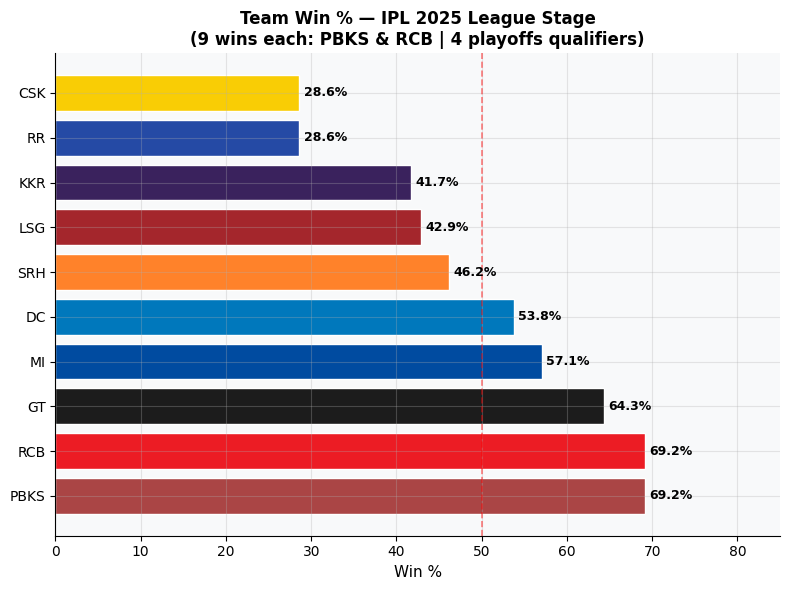

In [68]:
# CELL 9 — CORRECTED: Team Win % using verified league-stage standings
correct_win = pd.DataFrame({
    "Team"   : ["PBKS","RCB","GT","MI","DC","SRH","LSG","KKR","RR","CSK"],
    "WinPct" : [69.2,  69.2, 64.3,57.1,53.8,46.2, 42.9, 41.7,28.6,28.6],
}).sort_values("WinPct", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8,6))
cols = [TEAM_COLORS.get(t,"#888") for t in correct_win["Team"]]
bars = plt.barh(correct_win["Team"], correct_win["WinPct"], color=cols, edgecolor="white")

for bar, val in zip(bars, correct_win["WinPct"]):
    plt.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f"{val}%", va="center", fontsize=9, fontweight="bold")

plt.axvline(50, color="red", linestyle="--", alpha=0.5, linewidth=1.2)
plt.xlabel("Win %")
plt.title("Team Win % — IPL 2025 League Stage\n(9 wins each: PBKS & RCB | 4 playoffs qualifiers)")
plt.xlim(0, 85)
plt.tight_layout()
plt.show()

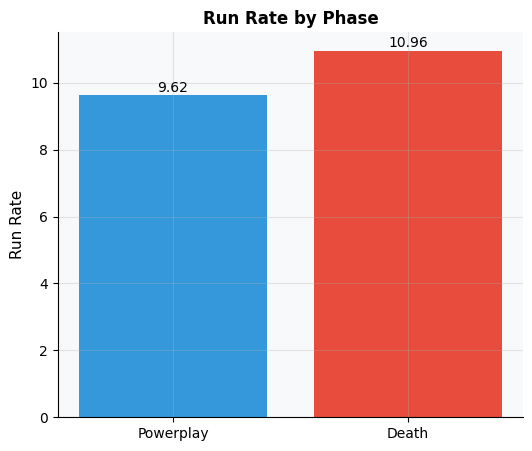

In [22]:
plt.figure(figsize=(6,5))
ph_cols = ["#3498db","#e74c3c"]

bars = plt.bar(phase_df["Phase"], phase_df["Run Rate"], color=ph_cols)

for bar, val in zip(bars, phase_df["Run Rate"]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{val}", ha="center")

plt.ylabel("Run Rate")
plt.title("Run Rate by Phase")
plt.show()

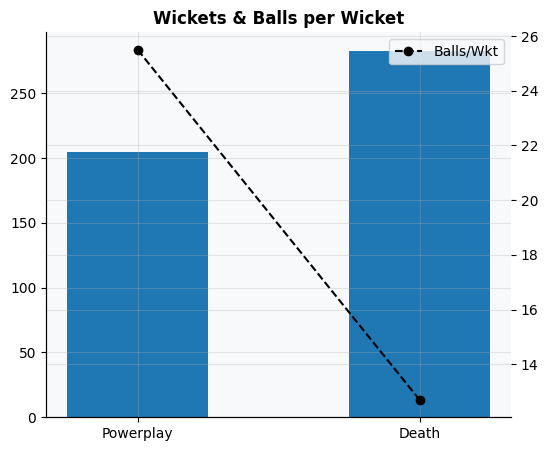

In [23]:
plt.figure(figsize=(6,5))
x = np.arange(len(phase_df))

plt.bar(x, phase_df["Wickets"], width=0.5, label="Wickets")

ax2 = plt.gca().twinx()
ax2.plot(x, phase_df["Balls/Wicket"], "ko--", label="Balls/Wkt")

plt.xticks(x, phase_df["Phase"])
plt.title("Wickets & Balls per Wicket")

plt.legend()
plt.show()

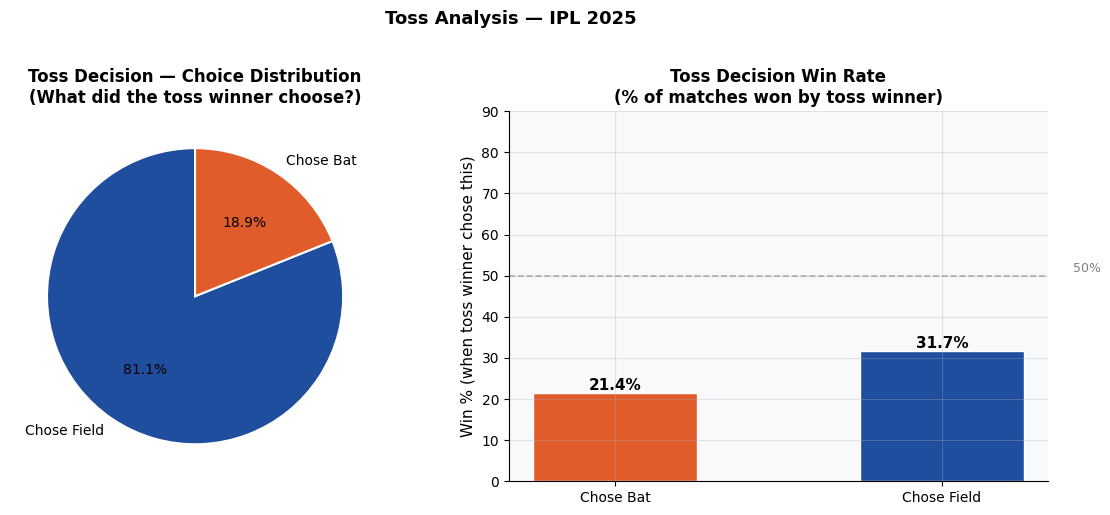

In [69]:
# CELL 12 — CORRECTED: Two subplots — (1) toss choice % pie, (2) win rate bar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Toss choice distribution (sums to 100%) ---
toss_dist  = mat_res["toss_decision"].value_counts()
labels     = ["Chose Field", "Chose Bat"]
sizes      = [toss_dist.get("field", 0), toss_dist.get("bat", 0)]
colors_pie = ["#1f4e9e", "#e05c2a"]

axes[0].pie(sizes, labels=labels, colors=colors_pie,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("Toss Decision — Choice Distribution\n(What did the toss winner choose?)")

# --- Right: Win % when toss winner chose bat vs field ---
bat_win = mat_res[mat_res["toss_decision"]=="bat"]["toss_winner_won"].mean() * 100
fld_win = mat_res[mat_res["toss_decision"]=="field"]["toss_winner_won"].mean() * 100

bars = axes[1].bar(["Chose Bat", "Chose Field"], [bat_win, fld_win],
                   color=["#e05c2a", "#1f4e9e"], edgecolor="white", width=0.5)
for bar, val in zip(bars, [bat_win, fld_win]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

axes[1].axhline(50, color="gray", linestyle="--", alpha=0.6, linewidth=1.2)
axes[1].text(1.4, 51, "50%", color="gray", fontsize=9)
axes[1].set_ylabel("Win % (when toss winner chose this)")
axes[1].set_ylim(0, 90)
axes[1].set_title("Toss Decision Win Rate\n(% of matches won by toss winner)")

plt.suptitle("Toss Analysis — IPL 2025", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

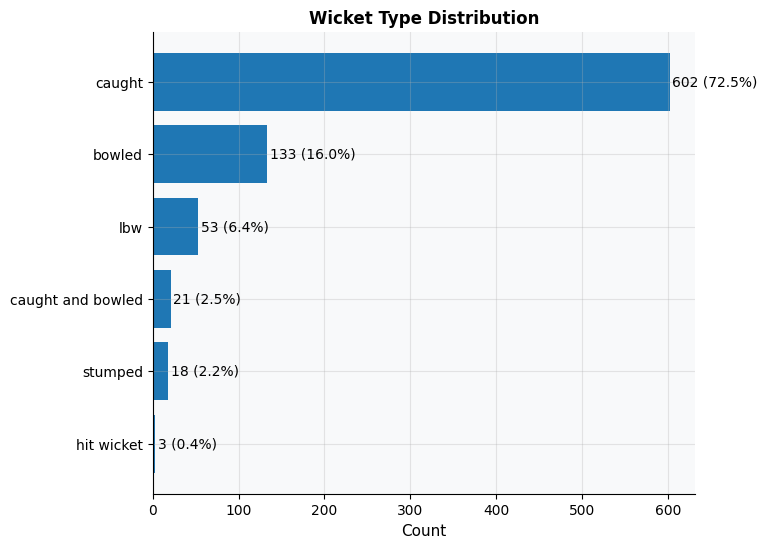

In [25]:
plt.figure(figsize=(7,6))

wkt_s = wkt.sort_values("Count")

bars = plt.barh(wkt_s["Type"], wkt_s["Count"])

for bar, val, pct in zip(bars, wkt_s["Count"], wkt_s["Pct"]):
    plt.text(val+3, bar.get_y()+bar.get_height()/2,
             f"{val} ({pct}%)", va="center")

plt.title("Wicket Type Distribution")
plt.xlabel("Count")
plt.show()

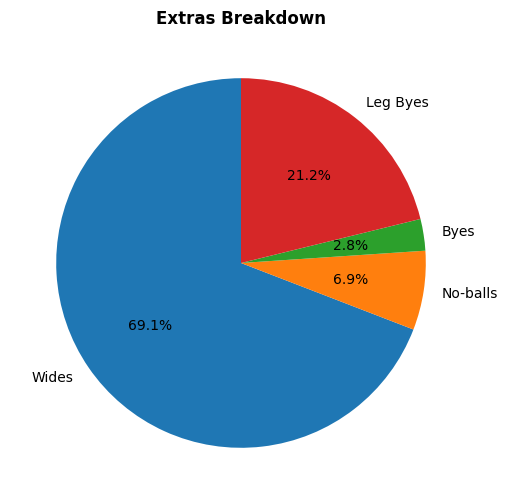

In [26]:
plt.figure(figsize=(6,6))

extras = {
    "Wides": bbb["is_wide"].sum(),
    "No-balls": bbb["is_noball"].sum(),
    "Byes": bbb["is_bye"].sum(),
    "Leg Byes": bbb["is_legbye"].sum()
}

plt.pie(
    list(extras.values()),
    labels=list(extras.keys()),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Extras Breakdown")
plt.show()

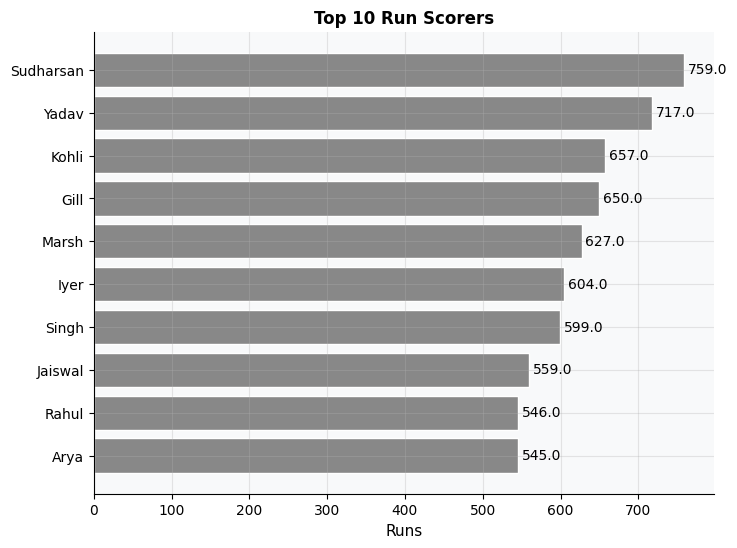

In [67]:
plt.figure(figsize=(8,6))

all_bat = pd.concat([
    bat[["Player","Team","RUNS","Price_Cr"]],
    ar[["Player","Team","RUNS","Price_Cr"]].rename(columns={"RUNS":"RUNS"})
], ignore_index=True)
top10 = all_bat.nlargest(10, "RUNS")[["Player","Team","RUNS","Price_Cr"]].reset_index(drop=True).sort_values("RUNS", ascending=False)
top10["short"] = top10["Player"].apply(lambda x: x.split()[-1])
cols = [TEAM_COLORS.get(t,"#888") for t in top10["Team"]]
bars = plt.barh(top10["short"], top10["RUNS"], color=cols, edgecolor="white")
for bar, val in zip(bars, top10["RUNS"]):
    plt.text(val+5, bar.get_y()+bar.get_height()/2, str(val), va="center")

plt.xlabel("Runs")
plt.title("Top 10 Run Scorers")
plt.gca().invert_yaxis()
plt.show()

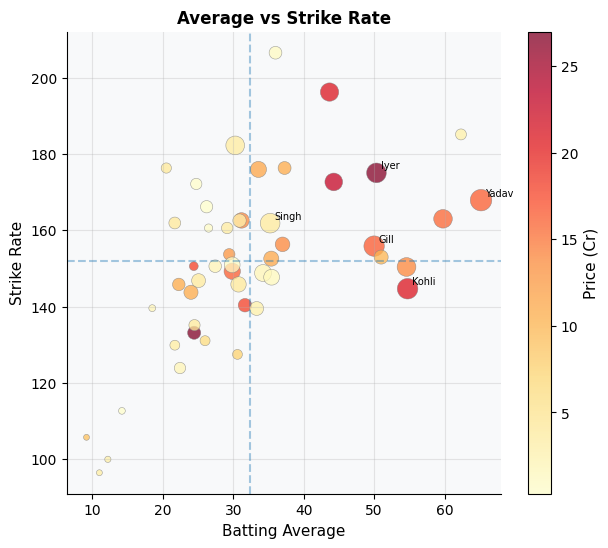

In [28]:
plt.figure(figsize=(7,6))

vb = bat.dropna(subset=["AVG","SR"]).query("INN >= 5")

sc = plt.scatter(vb["AVG"], vb["SR"],
                 c=vb["Price_Cr"], cmap="YlOrRd",
                 s=vb["RUNS"]/3, alpha=0.75,
                 edgecolors="gray", linewidth=0.4)

plt.colorbar(sc, label="Price (Cr)")

plt.axvline(vb["AVG"].mean(), linestyle="--", alpha=0.4)
plt.axhline(vb["SR"].mean(), linestyle="--", alpha=0.4)

plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.title("Average vs Strike Rate")

for _, row in vb.nlargest(5,"RUNS").iterrows():
    plt.annotate(row["Player"].split()[-1],
                 (row["AVG"], row["SR"]),
                 fontsize=7, xytext=(3,3),
                 textcoords="offset points")

plt.show()

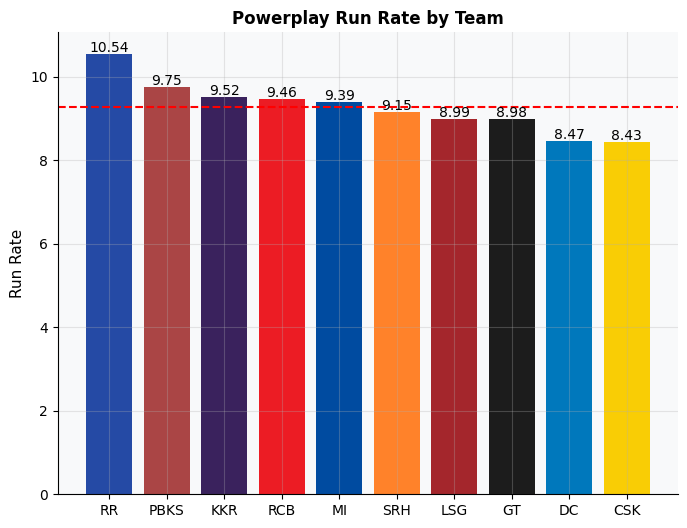

In [29]:
plt.figure(figsize=(8,6))

pp = (bbb[(bbb["phase"]=="Powerplay") & (bbb["is_legal"]==1)]
      .groupby("bat_team_abbr")
      .agg(r=("total_runs","sum"), b=("is_legal","sum"))
      .reset_index())

pp["pp_rr"] = (pp["r"]/pp["b"]*6).round(2)
pp = pp.sort_values("pp_rr", ascending=False)

cols = [TEAM_COLORS.get(t,"#888") for t in pp["bat_team_abbr"]]
bars = plt.bar(pp["bat_team_abbr"], pp["pp_rr"], color=cols)

for bar, val in zip(bars, pp["pp_rr"]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f"{val}", ha="center")

plt.axhline(pp["pp_rr"].mean(), linestyle="--", color="red")
plt.ylabel("Run Rate")
plt.title("Powerplay Run Rate by Team")
plt.show()

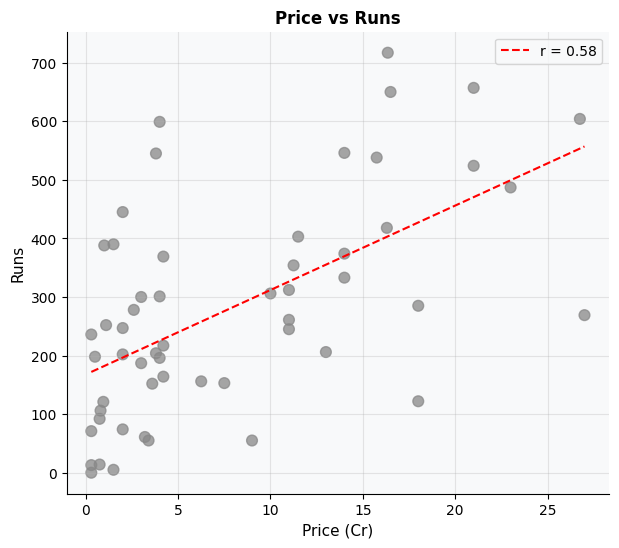

In [30]:
plt.figure(figsize=(7,6))

vb2 = bat.dropna(subset=["Price_Cr"])

plt.scatter(vb2["Price_Cr"], vb2["RUNS"],
            c=[TEAM_COLORS.get(t,"#888") for t in vb2["Team"]],
            s=60, alpha=0.75)

z = np.polyfit(vb2["Price_Cr"], vb2["RUNS"], 1)
xln = np.linspace(vb2["Price_Cr"].min(), vb2["Price_Cr"].max(), 100)

plt.plot(xln, np.polyval(z, xln), "r--",
         label=f"r = {vb2['Price_Cr'].corr(vb2['RUNS']):.2f}")

plt.xlabel("Price (Cr)")
plt.ylabel("Runs")
plt.title("Price vs Runs")
plt.legend()
plt.show()

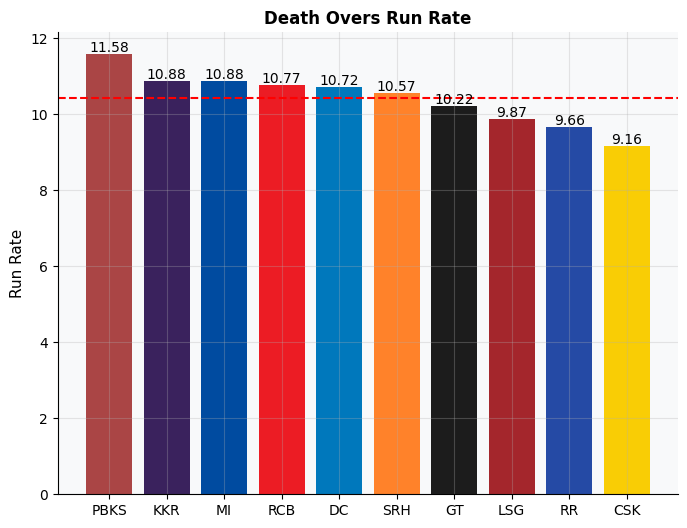

In [31]:
plt.figure(figsize=(8,6))

de = (bbb[(bbb["phase"]=="Death") & (bbb["is_legal"]==1)]
      .groupby("bat_team_abbr")
      .agg(r=("total_runs","sum"), b=("is_legal","sum"))
      .reset_index())

de["de_rr"] = (de["r"]/de["b"]*6).round(2)
de = de.sort_values("de_rr", ascending=False)

cols = [TEAM_COLORS.get(t,"#888") for t in de["bat_team_abbr"]]
bars = plt.bar(de["bat_team_abbr"], de["de_rr"], color=cols)

for bar, val in zip(bars, de["de_rr"]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f"{val}", ha="center")

plt.axhline(de["de_rr"].mean(), linestyle="--", color="red")
plt.ylabel("Run Rate")
plt.title("Death Overs Run Rate")
plt.show()

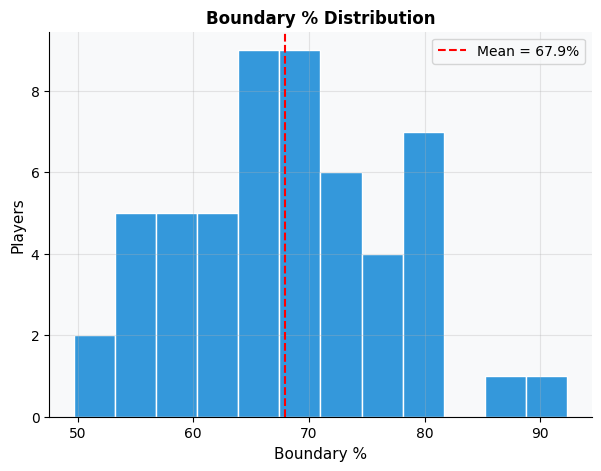

In [32]:
plt.figure(figsize=(7,5))

vbnd = bat.dropna(subset=["boundary_pct"])

plt.hist(vbnd["boundary_pct"], bins=12,
         color="#3498db", edgecolor="white")

plt.axvline(vbnd["boundary_pct"].mean(),
            linestyle="--", color="red",
            label=f"Mean = {vbnd['boundary_pct'].mean():.1f}%")

plt.xlabel("Boundary %")
plt.ylabel("Players")
plt.title("Boundary % Distribution")
plt.legend()
plt.show()

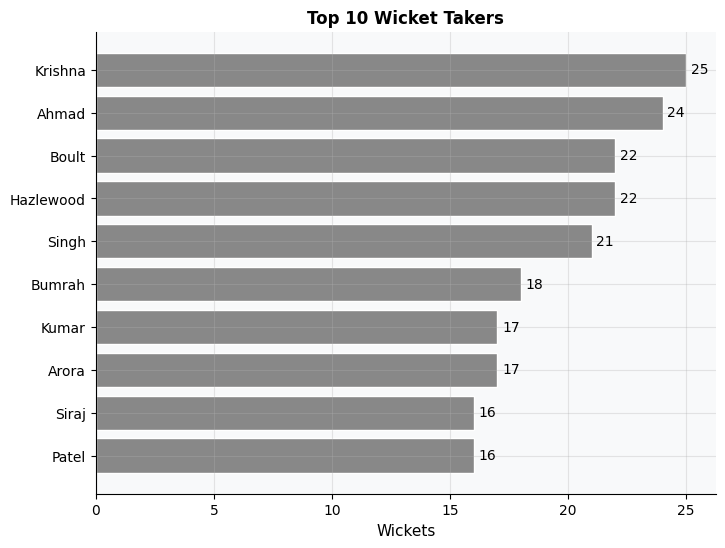

In [33]:
plt.figure(figsize=(8,6))

top10b = bowl.nlargest(10,"WKTS")[["Player","Team","WKTS","ECON"]].reset_index(drop=True)
top10b["short"] = top10b["Player"].apply(lambda x: x.split()[-1])

cols = [TEAM_COLORS.get(t,"#888") for t in top10b["Team"]]
bars = plt.barh(top10b["short"], top10b["WKTS"], color=cols, edgecolor="white")

for bar, val in zip(bars, top10b["WKTS"]):
    plt.text(val+0.2, bar.get_y()+bar.get_height()/2, str(val), va="center")

plt.xlabel("Wickets")
plt.title("Top 10 Wicket Takers")
plt.gca().invert_yaxis()
plt.show()

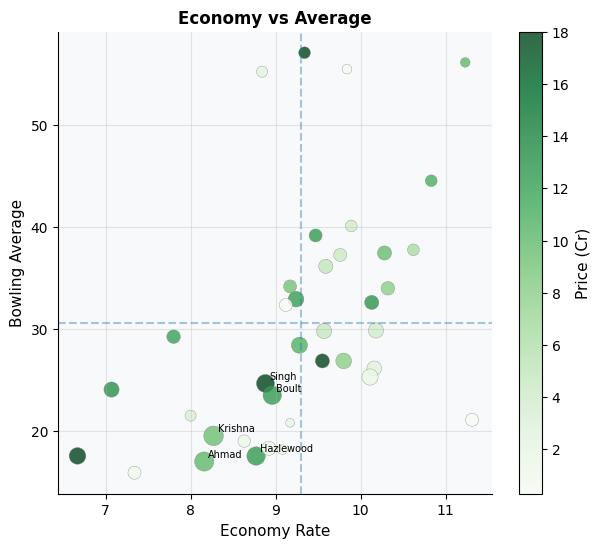

In [34]:
plt.figure(figsize=(7,6))

vbl = bowl[(bowl["WKTS"] >= 5) & bowl["AVG"].notna()]

sc = plt.scatter(vbl["ECON"], vbl["AVG"],
                 c=vbl["Price_Cr"], cmap="Greens",
                 s=vbl["WKTS"]*8, alpha=0.8,
                 edgecolors="gray", linewidth=0.3)

plt.colorbar(sc, label="Price (Cr)")

plt.axvline(vbl["ECON"].mean(), linestyle="--", alpha=0.4)
plt.axhline(vbl["AVG"].mean(), linestyle="--", alpha=0.4)

plt.xlabel("Economy Rate")
plt.ylabel("Bowling Average")
plt.title("Economy vs Average")

for _, row in vbl.nlargest(5,"WKTS").iterrows():
    plt.annotate(row["Player"].split()[-1],
                 (row["ECON"], row["AVG"]),
                 fontsize=7, xytext=(3,3),
                 textcoords="offset points")

plt.show()

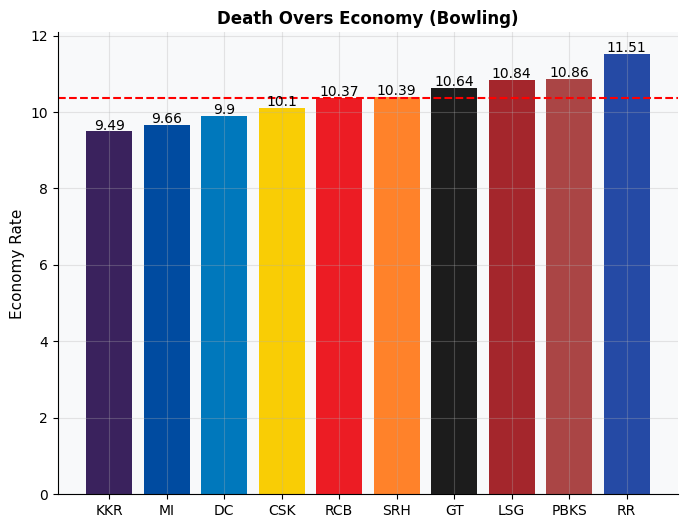

In [35]:
plt.figure(figsize=(8,6))

de_bowl = (bbb[(bbb["phase"]=="Death") & (bbb["is_legal"]==1)]
           .groupby("bowl_team_abbr")
           .agg(rc=("total_runs","sum"), balls=("is_legal","sum"),
                wkts=("bowler_wicket","sum"))
           .reset_index())

de_bowl["econ"] = (de_bowl["rc"]/de_bowl["balls"]*6).round(2)
de_bowl = de_bowl.sort_values("econ")

cols = [TEAM_COLORS.get(t,"#888") for t in de_bowl["bowl_team_abbr"]]
bars = plt.bar(de_bowl["bowl_team_abbr"], de_bowl["econ"], color=cols)

for bar, val in zip(bars, de_bowl["econ"]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f"{val}", ha="center")

plt.axhline(de_bowl["econ"].mean(), linestyle="--", color="red")
plt.ylabel("Economy Rate")
plt.title("Death Overs Economy (Bowling)")
plt.show()

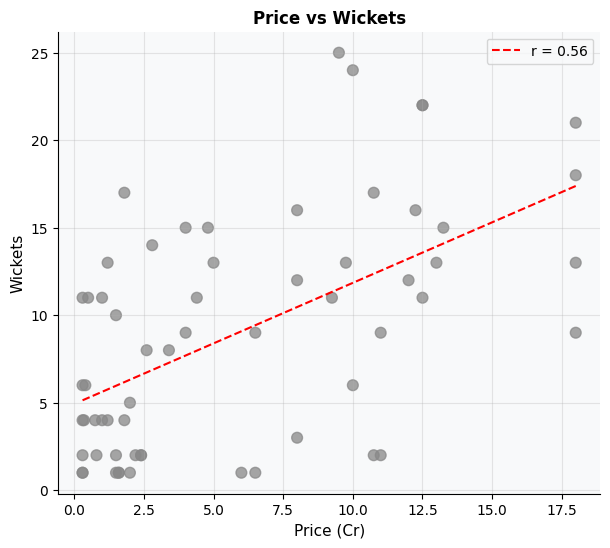

In [36]:
plt.figure(figsize=(7,6))

vbl2 = bowl.dropna(subset=["Price_Cr"])

plt.scatter(vbl2["Price_Cr"], vbl2["WKTS"],
            c=[TEAM_COLORS.get(t,"#888") for t in vbl2["Team"]],
            s=60, alpha=0.75)

z = np.polyfit(vbl2["Price_Cr"], vbl2["WKTS"], 1)
xln = np.linspace(vbl2["Price_Cr"].min(), vbl2["Price_Cr"].max(), 100)

plt.plot(xln, np.polyval(z, xln), "r--",
         label=f"r = {vbl2['Price_Cr'].corr(vbl2['WKTS']):.2f}")

plt.xlabel("Price (Cr)")
plt.ylabel("Wickets")
plt.title("Price vs Wickets")
plt.legend()
plt.show()

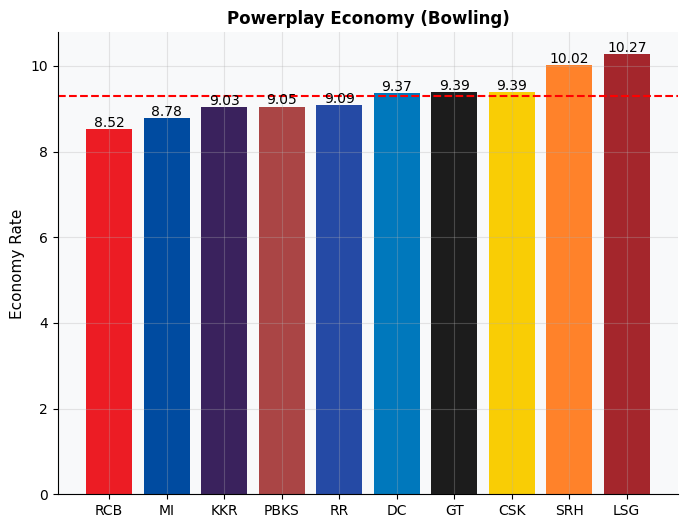

In [37]:
plt.figure(figsize=(8,6))

pp_bowl = (bbb[(bbb["phase"]=="Powerplay") & (bbb["is_legal"]==1)]
           .groupby("bowl_team_abbr")
           .agg(rc=("total_runs","sum"), balls=("is_legal","sum"))
           .reset_index())

pp_bowl["pp_econ"] = (pp_bowl["rc"]/pp_bowl["balls"]*6).round(2)
pp_bowl = pp_bowl.sort_values("pp_econ")

cols = [TEAM_COLORS.get(t,"#888") for t in pp_bowl["bowl_team_abbr"]]
bars = plt.bar(pp_bowl["bowl_team_abbr"], pp_bowl["pp_econ"], color=cols)

for bar, val in zip(bars, pp_bowl["pp_econ"]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f"{val}", ha="center")

plt.axhline(pp_bowl["pp_econ"].mean(), linestyle="--", color="red")
plt.ylabel("Economy Rate")
plt.title("Powerplay Economy (Bowling)")
plt.show()

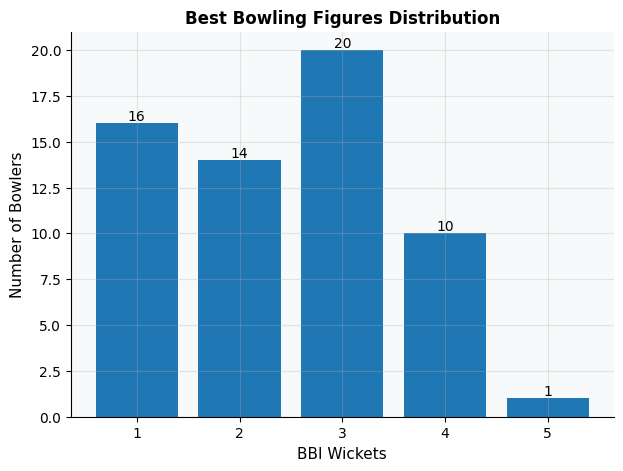

In [38]:
plt.figure(figsize=(7,5))

bbi_c = bowl.dropna(subset=["BBI_wickets"])["BBI_wickets"].value_counts().sort_index()

bars = plt.bar(bbi_c.index.astype(str), bbi_c.values)

for bar, val in zip(bars, bbi_c.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
             str(val), ha="center")

plt.xlabel("BBI Wickets")
plt.ylabel("Number of Bowlers")
plt.title("Best Bowling Figures Distribution")
plt.show()

In [39]:
all_players = pd.concat([
    bat[["Player","Team","Price_Cr","Status"]].assign(Role="Batter"),
    bowl[["Player","Team","Price_Cr","Status"]].assign(Role="Bowler"),
    ar[["Player","Team","Price_Cr","Status"]].assign(Role="All-Rounder"),
], ignore_index=True)

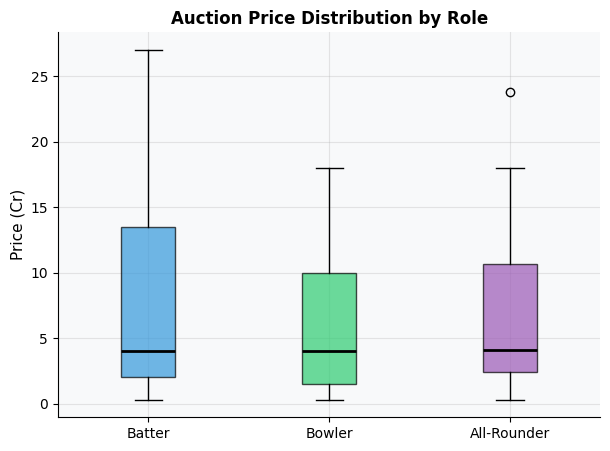

In [40]:
plt.figure(figsize=(7,5))

roles = ["Batter","Bowler","All-Rounder"]
data_bp = [all_players[all_players["Role"]==r]["Price_Cr"].dropna() for r in roles]

bp = plt.boxplot(data_bp, labels=roles, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))

for patch, col in zip(bp["boxes"], ["#3498db","#2ecc71","#9b59b6"]):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

plt.ylabel("Price (Cr)")
plt.title("Auction Price Distribution by Role")
plt.show()

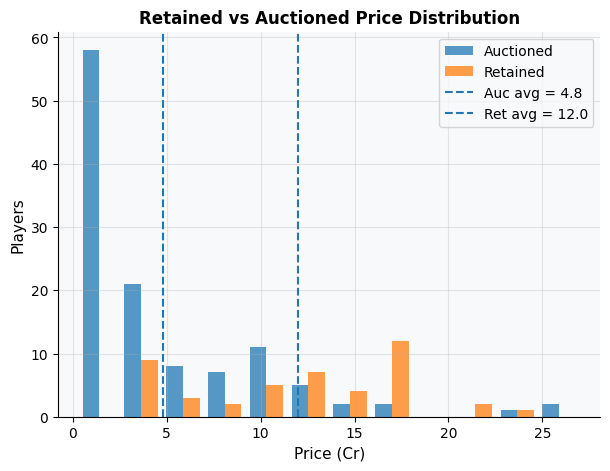

In [41]:
plt.figure(figsize=(7,5))

ret = all_players[all_players["Status"]=="Retained"]["Price_Cr"].dropna()
auc = all_players[all_players["Status"]=="Auctioned"]["Price_Cr"].dropna()

plt.hist([auc, ret], bins=12,
         label=["Auctioned","Retained"],
         alpha=0.75)

plt.axvline(auc.mean(), linestyle="--", label=f"Auc avg = {auc.mean():.1f}")
plt.axvline(ret.mean(), linestyle="--", label=f"Ret avg = {ret.mean():.1f}")

plt.xlabel("Price (Cr)")
plt.ylabel("Players")
plt.title("Retained vs Auctioned Price Distribution")
plt.legend()
plt.show()

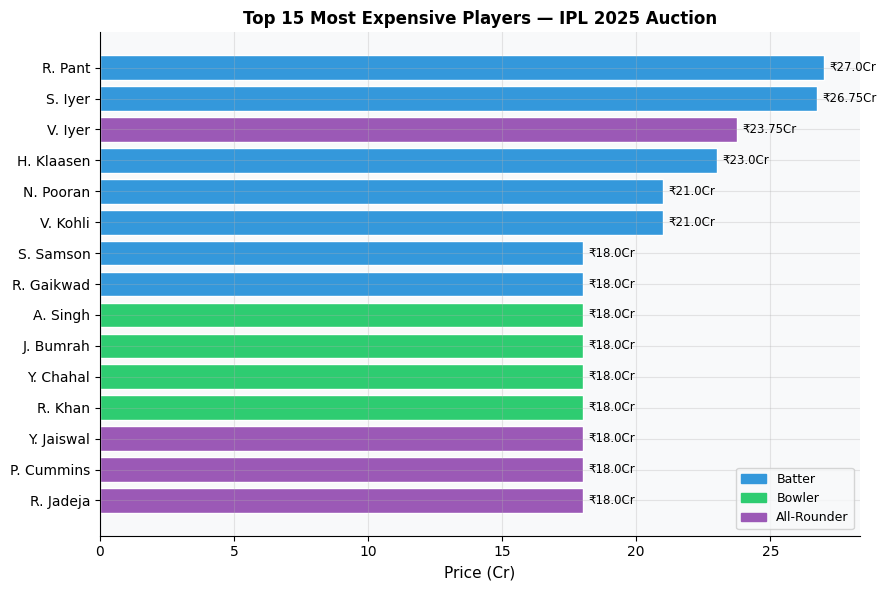

In [70]:
# CELL 30 — CORRECTED: Top 15 Most Expensive Players with unique name labels
plt.figure(figsize=(9, 6))

top15 = all_players.dropna(subset=["Price_Cr"]).nlargest(15, "Price_Cr").reset_index(drop=True)

# Fix: use "F. Lastname" format to make every label unique
def short_name(full):
    parts = full.strip().split()
    if len(parts) == 1:
        return full
    return f"{parts[0][0]}. {parts[-1]}"

top15["label"] = top15["Player"].apply(short_name)
role_col = {"Batter": "#3498db", "Bowler": "#2ecc71", "All-Rounder": "#9b59b6"}
bar_colors = [role_col.get(r, "#888") for r in top15["Role"]]

bars = plt.barh(top15["label"], top15["Price_Cr"], color=bar_colors, edgecolor="white")
for bar, val in zip(bars, top15["Price_Cr"]):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f"₹{val}Cr", va="center", fontsize=8.5)

plt.xlabel("Price (Cr)")
plt.title("Top 15 Most Expensive Players — IPL 2025 Auction")
plt.gca().invert_yaxis()

patches = [mpatches.Patch(color=v, label=k) for k, v in role_col.items()]
plt.legend(handles=patches, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

In [43]:
team_map = {
    "Mumbai Indians":"MI","Chennai Super Kings":"CSK",
    "Royal Challengers Bengaluru":"RCB","Kolkata Knight Riders":"KKR",
    "Sunrisers Hyderabad":"SRH","Rajasthan Royals":"RR",
    "Gujarat Titans":"GT","Lucknow Super Giants":"LSG",
    "Delhi Capitals":"DC","Punjab Kings":"PBKS",
}

all_players["Team_abbr"] = all_players["Team"].map(team_map).fillna(all_players["Team"])

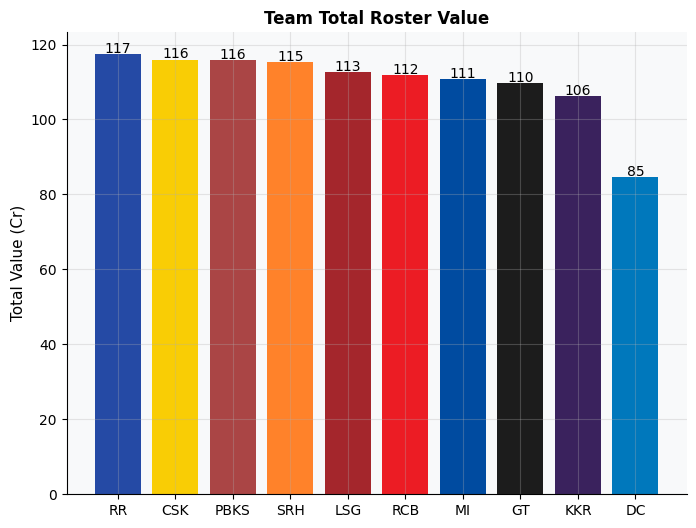

In [44]:
plt.figure(figsize=(8,6))

spend = all_players.groupby("Team_abbr")["Price_Cr"].sum().sort_values(ascending=False)

bars = plt.bar(spend.index, spend.values,
               color=[TEAM_COLORS.get(t,"#888") for t in spend.index])

for bar, val in zip(bars, spend.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.0f}", ha="center")

plt.ylabel("Total Value (Cr)")
plt.title("Team Total Roster Value")
plt.show()

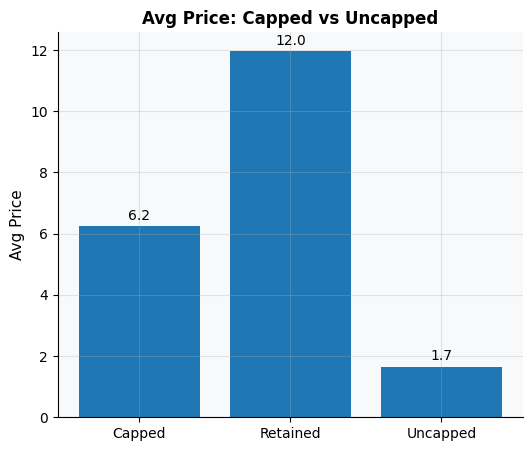

In [45]:
plt.figure(figsize=(6,5))

all_cap = pd.concat([
    bat[["Capped","Price_Cr"]],
    bowl[["Capped","Price_Cr"]],
    ar[["Capped","Price_Cr"]]
])

cap_mean = all_cap.groupby("Capped")["Price_Cr"].mean()

bars = plt.bar(cap_mean.index, cap_mean.values)

for i, val in enumerate(cap_mean.values):
    plt.text(i, val+0.2, f"{val:.1f}", ha="center")

plt.ylabel("Avg Price")
plt.title("Avg Price: Capped vs Uncapped")
plt.show()

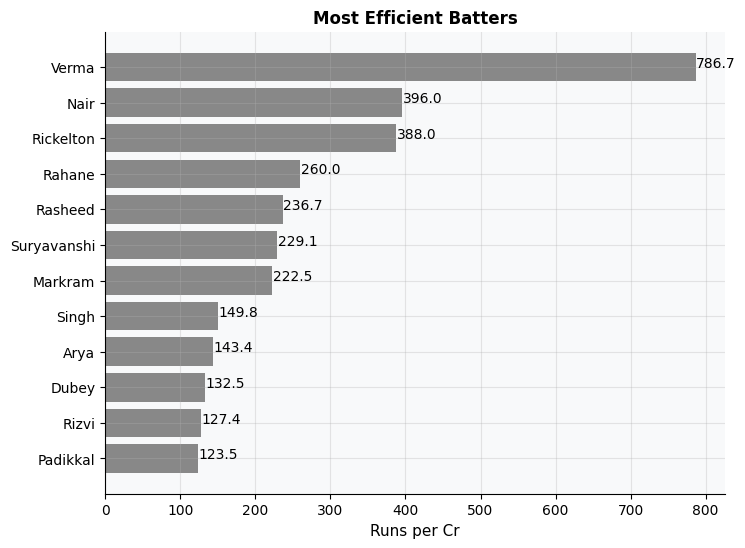

In [46]:
plt.figure(figsize=(8,6))

eff = bat.dropna(subset=["Price_Cr"]).query("Price_Cr > 0").copy()
eff["runs_per_cr"] = (eff["RUNS"] / eff["Price_Cr"]).round(1)

top_eff = eff.nlargest(12,"runs_per_cr")

cols = [TEAM_COLORS.get(t,"#888") for t in top_eff["Team"]]

bars = plt.barh(top_eff["Player"].apply(lambda x: x.split()[-1]),
                top_eff["runs_per_cr"], color=cols)

for bar, val in zip(bars, top_eff["runs_per_cr"]):
    plt.text(val+0.5, bar.get_y()+bar.get_height()/2, f"{val}")

plt.xlabel("Runs per Cr")
plt.title("Most Efficient Batters")
plt.gca().invert_yaxis()
plt.show()

In [47]:
venue_inn = (
    bbb.groupby(["venue","match_id","innings"])["total_runs"]
       .sum()
       .reset_index()
       .groupby("venue")["total_runs"]
       .mean()
       .sort_values(ascending=False)
       .round(1)
       .reset_index()
)

venue_inn.columns = ["venue","avg_score"]

venue_inn["venue_short"] = venue_inn["venue"].apply(
    lambda x: x.split(",")[0]
               .replace(" International","")
               .replace(" Cricket","")
               .replace(" Stadium","")
               .strip()[:22]
)

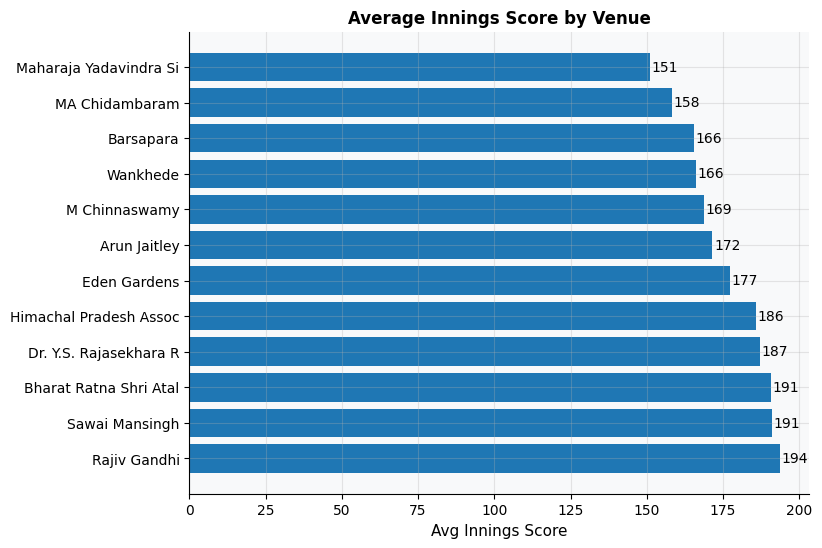

In [48]:
plt.figure(figsize=(8,6))

v_show = venue_inn.tail(12)

bars = plt.barh(v_show["venue_short"], v_show["avg_score"])

for bar, val in zip(bars, v_show["avg_score"]):
    plt.text(val+0.5, bar.get_y()+bar.get_height()/2, f"{val:.0f}", va="center")

plt.xlabel("Avg Innings Score")
plt.title("Average Innings Score by Venue")
plt.show()

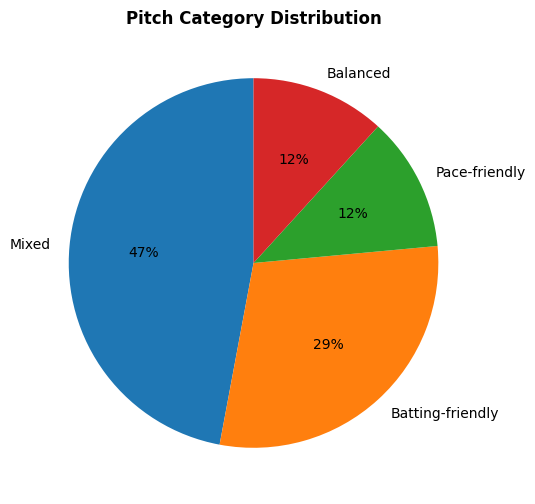

In [49]:
plt.figure(figsize=(6,6))

pc = vn["pitch_category"].value_counts()

plt.pie(pc.values, labels=pc.index, autopct="%1.0f%%", startangle=90)

plt.title("Pitch Category Distribution")
plt.show()

In [50]:
print(inn_sc.columns)

Index(['match_id', 'inn1', 'inn2', 'chase_won', 'bat_first_won'], dtype='object')


In [51]:
inn_sc = (
    bbb.groupby(["match_id","innings"])["runs_so_far"]
       .max()
       .reset_index()
       .pivot(index="match_id", columns="innings", values="runs_so_far")
       .reset_index()
)
inn_sc = inn_sc[["match_id", 1, 2]]
inn_sc.columns = ["match_id","inn1","inn2"]
inn_sc["chase_won"] = (inn_sc["inn2"] >= inn_sc["inn1"]).astype(int)

# 2) Attach venue to each match
pv2 = inn_sc.merge(
    bbb[bbb["innings"]==1].groupby("match_id")["venue"].first().reset_index(),
    on="match_id", how="left"
)

# 3) Clean short venue names
pv2["venue_short"] = pv2["venue"].apply(
    lambda x: str(x).split(",")[0]
        .replace(" International","")
        .replace(" Cricket","")
        .replace(" Stadium","")
        .strip()[:20]
)

# 4) Compute chase win %
chase_v = (
    pv2.groupby("venue_short")
       .agg(m=("chase_won","count"), cw=("chase_won","sum"))
       .reset_index()
)

# keep venues with enough matches
chase_v = chase_v[chase_v["m"] >= 4].copy()

# percentage
chase_v["cpct"] = (chase_v["cw"] / chase_v["m"] * 100).round(1)

# sort (optional)
chase_v = chase_v.sort_values("cpct", ascending=True).reset_index(drop=True)

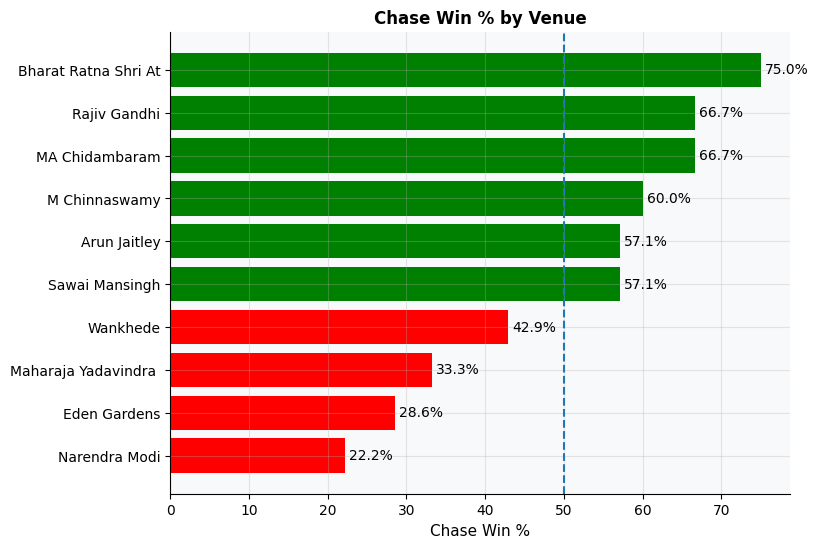

In [52]:
plt.figure(figsize=(8,6))

bar_cols = ["red" if v < 50 else "green" for v in chase_v["cpct"]]

bars = plt.barh(chase_v["venue_short"], chase_v["cpct"], color=bar_cols)

plt.axvline(50, linestyle="--")

for bar, val in zip(bars, chase_v["cpct"]):
    plt.text(val+0.5, bar.get_y()+bar.get_height()/2, f"{val}%", va="center")

plt.xlabel("Chase Win %")
plt.title("Chase Win % by Venue")
plt.show()

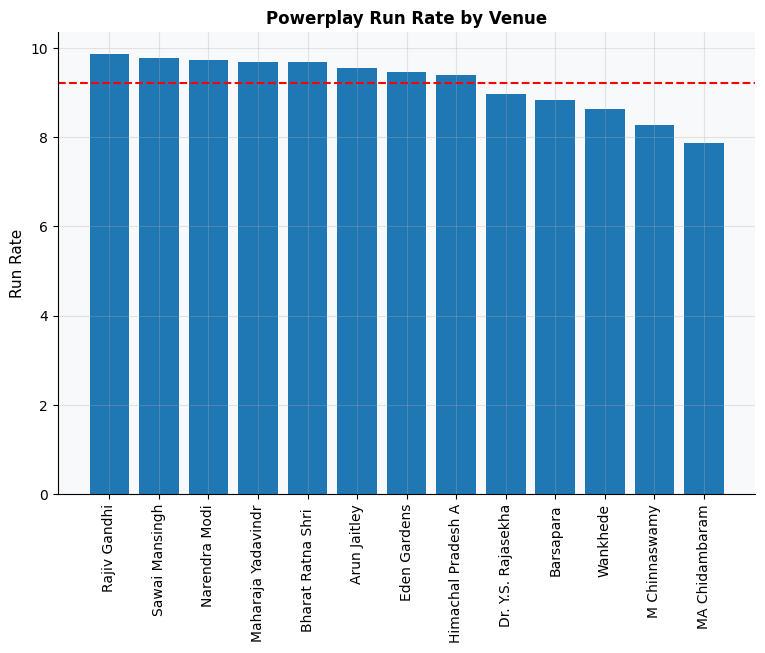

In [53]:
pp_v = bbb[(bbb["phase"]=="Powerplay") & (bbb["is_legal"]==1)].copy()

pp_v["vs"] = pp_v["venue"].apply(
    lambda x: str(x).split(",")[0]
        .replace(" International","")
        .replace(" Cricket","")
        .replace(" Stadium","")
        .strip()[:18]
)

ppv = (
    pp_v.groupby("vs")
        .agg(r=("total_runs","sum"), b=("is_legal","sum"))
        .reset_index()
)

ppv = ppv[ppv["b"] >= 60]   # filter low sample
ppv["rr"] = (ppv["r"] / ppv["b"] * 6).round(2)

ppv = ppv.sort_values("rr", ascending=False)

plt.figure(figsize=(9,6))
bars = plt.bar(range(len(ppv)), ppv["rr"])
plt.xticks(range(len(ppv)), ppv["vs"], rotation=90)
plt.axhline(ppv["rr"].mean(), linestyle="--", color="red")
plt.ylabel("Run Rate")
plt.title("Powerplay Run Rate by Venue")
plt.show()

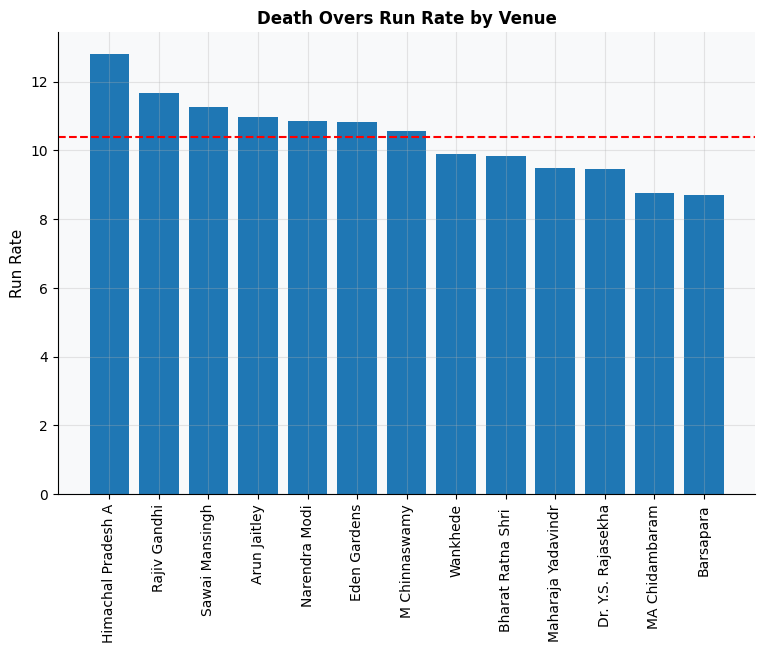

In [54]:
de_v = bbb[(bbb["phase"]=="Death") & (bbb["is_legal"]==1)].copy()

de_v["vs"] = de_v["venue"].apply(
    lambda x: str(x).split(",")[0]
        .replace(" International","")
        .replace(" Cricket","")
        .replace(" Stadium","")
        .strip()[:18]
)

dv = (
    de_v.groupby("vs")
        .agg(r=("total_runs","sum"), b=("is_legal","sum"))
        .reset_index()
)

dv = dv[dv["b"] >= 60]
dv["rr"] = (dv["r"] / dv["b"] * 6).round(2)

dv = dv.sort_values("rr", ascending=False)
plt.figure(figsize=(9,6))

bars = plt.bar(range(len(dv)), dv["rr"])

plt.xticks(range(len(dv)), dv["vs"], rotation=90)

plt.axhline(dv["rr"].mean(), linestyle="--", color="red")

plt.ylabel("Run Rate")
plt.title("Death Overs Run Rate by Venue")
plt.show()

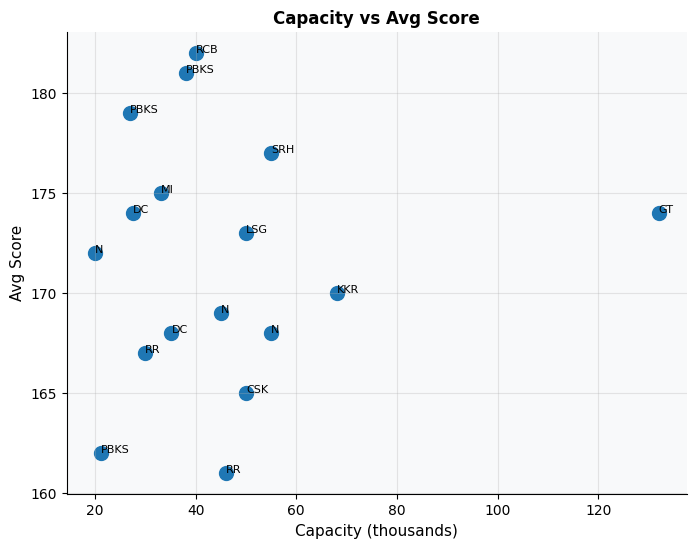

In [55]:
vn2 = vn.copy()

# convert columns to numeric
vn2["cap_num"] = pd.to_numeric(vn2["Capacity"], errors="coerce")
vn2["avg_s"]   = pd.to_numeric(vn2["avg_first_innings_score"], errors="coerce")

# drop missing
vv = vn2.dropna(subset=["cap_num","avg_s"]).copy()
plt.figure(figsize=(8,6))

plt.scatter(vv["cap_num"]/1000, vv["avg_s"], s=100)

for _, row in vv.iterrows():
    plt.annotate(row["Home_Team"],
                 (row["cap_num"]/1000, row["avg_s"]),
                 fontsize=8)

plt.xlabel("Capacity (thousands)")
plt.ylabel("Avg Score")
plt.title("Capacity vs Avg Score")
plt.show()

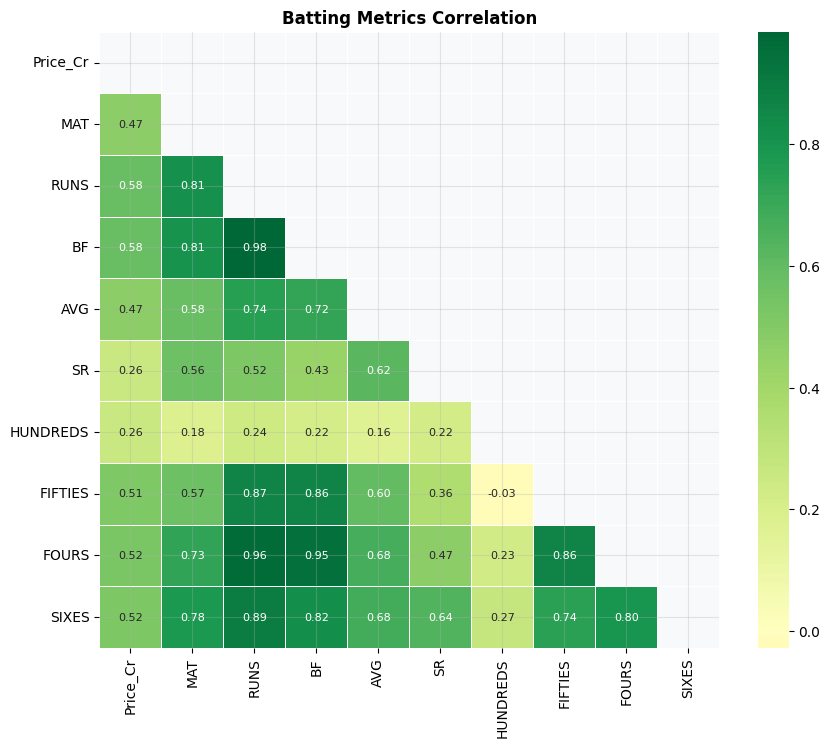

In [56]:
plt.figure(figsize=(10,8))

bat_corr_cols = ["Price_Cr","MAT","RUNS","BF","AVG","SR",
                 "HUNDREDS","FIFTIES","FOURS","SIXES"]

bat_c = bat[bat_corr_cols].dropna().corr()

mask = np.triu(np.ones_like(bat_c, dtype=bool))

sns.heatmap(bat_c, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            annot_kws={"size":8})

plt.title("Batting Metrics Correlation")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

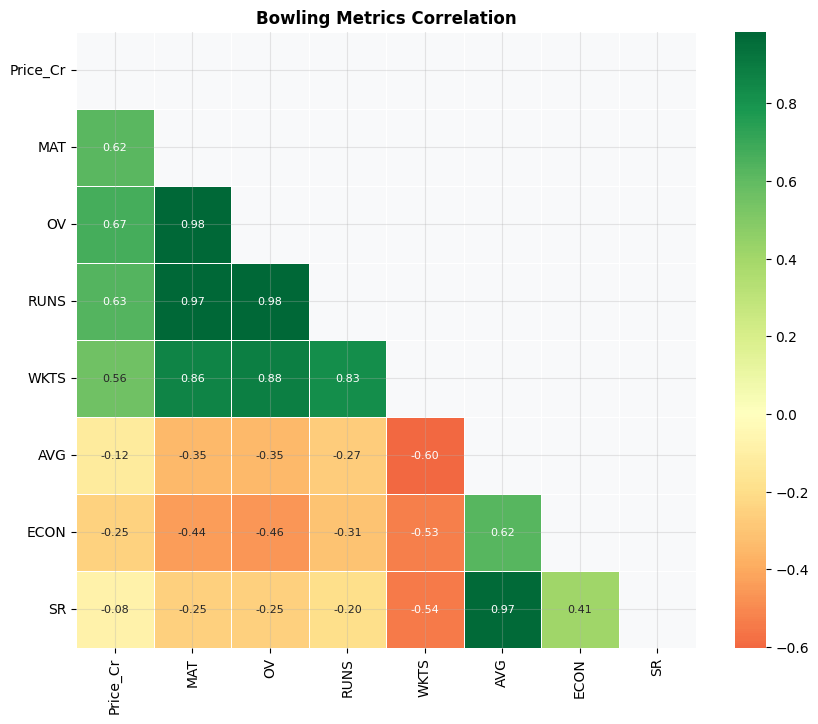

In [57]:
plt.figure(figsize=(10,8))

bowl_corr_cols = ["Price_Cr","MAT","OV","RUNS","WKTS","AVG","ECON","SR"]

bowl_c = bowl[bowl_corr_cols].dropna().corr()

mask2 = np.triu(np.ones_like(bowl_c, dtype=bool))

sns.heatmap(bowl_c, mask=mask2, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            annot_kws={"size":8})

plt.title("Bowling Metrics Correlation")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [85]:
all_bat = pd.concat([
    bat[["Player","Team","RUNS","BF","AVG","SR","INN","Price_Cr",
         "FOURS","SIXES","HUNDREDS","FIFTIES"]],
    ar[["Player","Team","RUNS","BF","Bat_AVG","Bat_SR","Bat_INN","Price_Cr",
        "FOURS","SIXES","HUNDREDS","FIFTIES"]].rename(
        columns={"Bat_AVG":"AVG","Bat_SR":"SR","Bat_INN":"INN"})
], ignore_index=True).dropna(subset=["RUNS"])
all_bat["Abbr"] = all_bat["Team"].map(team_map).fillna(all_bat["Team"])
 
bowl["Abbr"] = bowl["Team"].map(team_map).fillna(bowl["Team"])
 
# Price lookup for BBB-derived metrics
price_lookup = pd.concat([
    bat[["Player","Price_Cr"]],
    bowl[["Player","Price_Cr"]],
    ar[["Player","Price_Cr"]]
]).dropna().groupby("Player")["Price_Cr"].first()
 
print("Data loaded successfully.")

Data loaded successfully.


In [86]:
print("Building Fig 1: Value Quadrant...")
 
# ---- Batter score ----
bs = all_bat.dropna(subset=["Price_Cr","RUNS","SR","AVG"]).copy()
for col in ["RUNS","SR","AVG"]:
    mn, mx = bs[col].min(), bs[col].max()
    bs[f"{col}_n"] = (bs[col]-mn)/(mx-mn) if mx > mn else 0
bs["perf"]  = bs["RUNS_n"]*0.5 + bs["SR_n"]*0.3 + bs["AVG_n"]*0.2
p_mn, p_mx  = bs["Price_Cr"].min(), bs["Price_Cr"].max()
bs["price_n"]= (bs["Price_Cr"]-p_mn)/(p_mx-p_mn)
bs["value_idx"] = bs["perf"] - bs["price_n"]
 
# ---- Bowler score ----
bws = bowl.dropna(subset=["Price_Cr","WKTS","ECON","SR"]).copy()
bws["econ_inv"] = 1/bws["ECON"].replace(0, np.nan)
bws["sr_inv"]   = 1/bws["SR"].replace(0, np.nan)
for col in ["WKTS","econ_inv","sr_inv"]:
    mn, mx = bws[col].min(), bws[col].max()
    bws[f"{col}_n"] = (bws[col]-mn)/(mx-mn) if mx > mn else 0
bws["perf"]   = bws["WKTS_n"]*0.5 + bws["econ_inv_n"]*0.3 + bws["sr_inv_n"]*0.2
p_mn2, p_mx2  = bws["Price_Cr"].min(), bws["Price_Cr"].max()
bws["price_n"]= (bws["Price_Cr"]-p_mn2)/(p_mx2-p_mn2)
bws["value_idx"]= bws["perf"] - bws["price_n"]
 
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Batters — Price vs Performance Quadrant",
        "Bowlers — Price vs Performance Quadrant"
    ),
    horizontal_spacing=0.10
)
 
for col_idx, (df, title_sfx) in enumerate([(bs, "Batter"), (bws, "Bowler")], start=1):
    med_price = df["price_n"].median()
    med_perf  = df["perf"].median()
 
    for _, row in df.iterrows():
        team  = row.get("Abbr", "")
        color = TEAM_COLORS.get(team, "#888888")
        label = row["Player"].split()[-1]
 
        if row["price_n"] < med_price and row["perf"] >= med_perf:
            zone = "🟢 Undervalued"
        elif row["price_n"] >= med_price and row["perf"] >= med_perf:
            zone = "🔵 Star Player"
        elif row["price_n"] < med_price and row["perf"] < med_perf:
            zone = "⚪ Bargain"
        else:
            zone = "🔴 Overvalued"
 
        hover = (
            f"<b>{row['Player']}</b><br>"
            f"Team: {team}<br>"
            f"Price: ₹{row['Price_Cr']:.2f} Cr<br>"
            f"Perf Score: {row['perf']:.3f}<br>"
            f"Zone: {zone}"
        )
        if title_sfx == "Batter":
            hover += (f"<br>Runs: {int(row['RUNS'])}  Avg: {row['AVG']:.1f}  SR: {row['SR']:.1f}")
        else:
            hover += (f"<br>Wkts: {int(row['WKTS'])}  Econ: {row['ECON']:.2f}")
 
        fig.add_trace(go.Scatter(
            x=[row["price_n"]], y=[row["perf"]],
            mode="markers+text",
            marker=dict(size=11, color=color,
                        line=dict(width=1, color="white")),
            text=[label], textposition="top center",
            textfont=dict(size=8),
            hovertemplate=hover + "<extra></extra>",
            name=team, legendgroup=team,
            showlegend=(col_idx == 1)
        ), row=1, col=col_idx)
 
    # Quadrant dividers
    for fig_trace in [
        go.Scatter(x=[med_price, med_price], y=[0, 1],
                   mode="lines", line=dict(dash="dash", color="gray", width=1.2),
                   showlegend=False, hoverinfo="skip"),
        go.Scatter(x=[0, 1], y=[med_perf, med_perf],
                   mode="lines", line=dict(dash="dash", color="gray", width=1.2),
                   showlegend=False, hoverinfo="skip"),
    ]:
        fig.add_trace(fig_trace, row=1, col=col_idx)
 
    # Quadrant annotations
    for (ax, ay, txt, clr) in [
        (0.05, 0.95, "🟢 UNDERVALUED\nLow Price · High Perf", "#27ae60"),
        (0.75, 0.95, "🔵 STAR PLAYERS\nHigh Price · High Perf", "#2980b9"),
        (0.05, 0.10, "⚪ BARGAIN\nLow Price · Low Perf",  "#7f8c8d"),
        (0.75, 0.10, "🔴 OVERVALUED\nHigh Price · Low Perf", "#e74c3c"),
    ]:
        fig.add_annotation(
            x=ax, y=ay, xref=f"x{col_idx}", yref=f"y{col_idx}",
            text=txt, showarrow=False,
            font=dict(size=9, color=clr),
            bgcolor="rgba(255,255,255,0.75)", bordercolor=clr,
            borderwidth=1, borderpad=4
        )
 
fig.update_xaxes(title_text="Normalized Auction Price  →", range=[0,1])
fig.update_yaxes(title_text="Normalized Performance Score  →", range=[0,1])
fig.update_layout(
    title=dict(
        text="<b>IPL 2025 — Player Value Quadrant Analysis</b><br>",
        x=0.5, xanchor="center"
    ),
    height=620, width=1300,
    paper_bgcolor="white", plot_bgcolor="#F8F9FA",
    legend=dict(
        title="Team", orientation="h",
        x=0.5, xanchor="center", y=-0.12,
        bgcolor="rgba(255,255,255,0.8)"
    ),
    font=dict(family="Arial", size=11)
)
 
fig.show()

Building Fig 1: Value Quadrant...


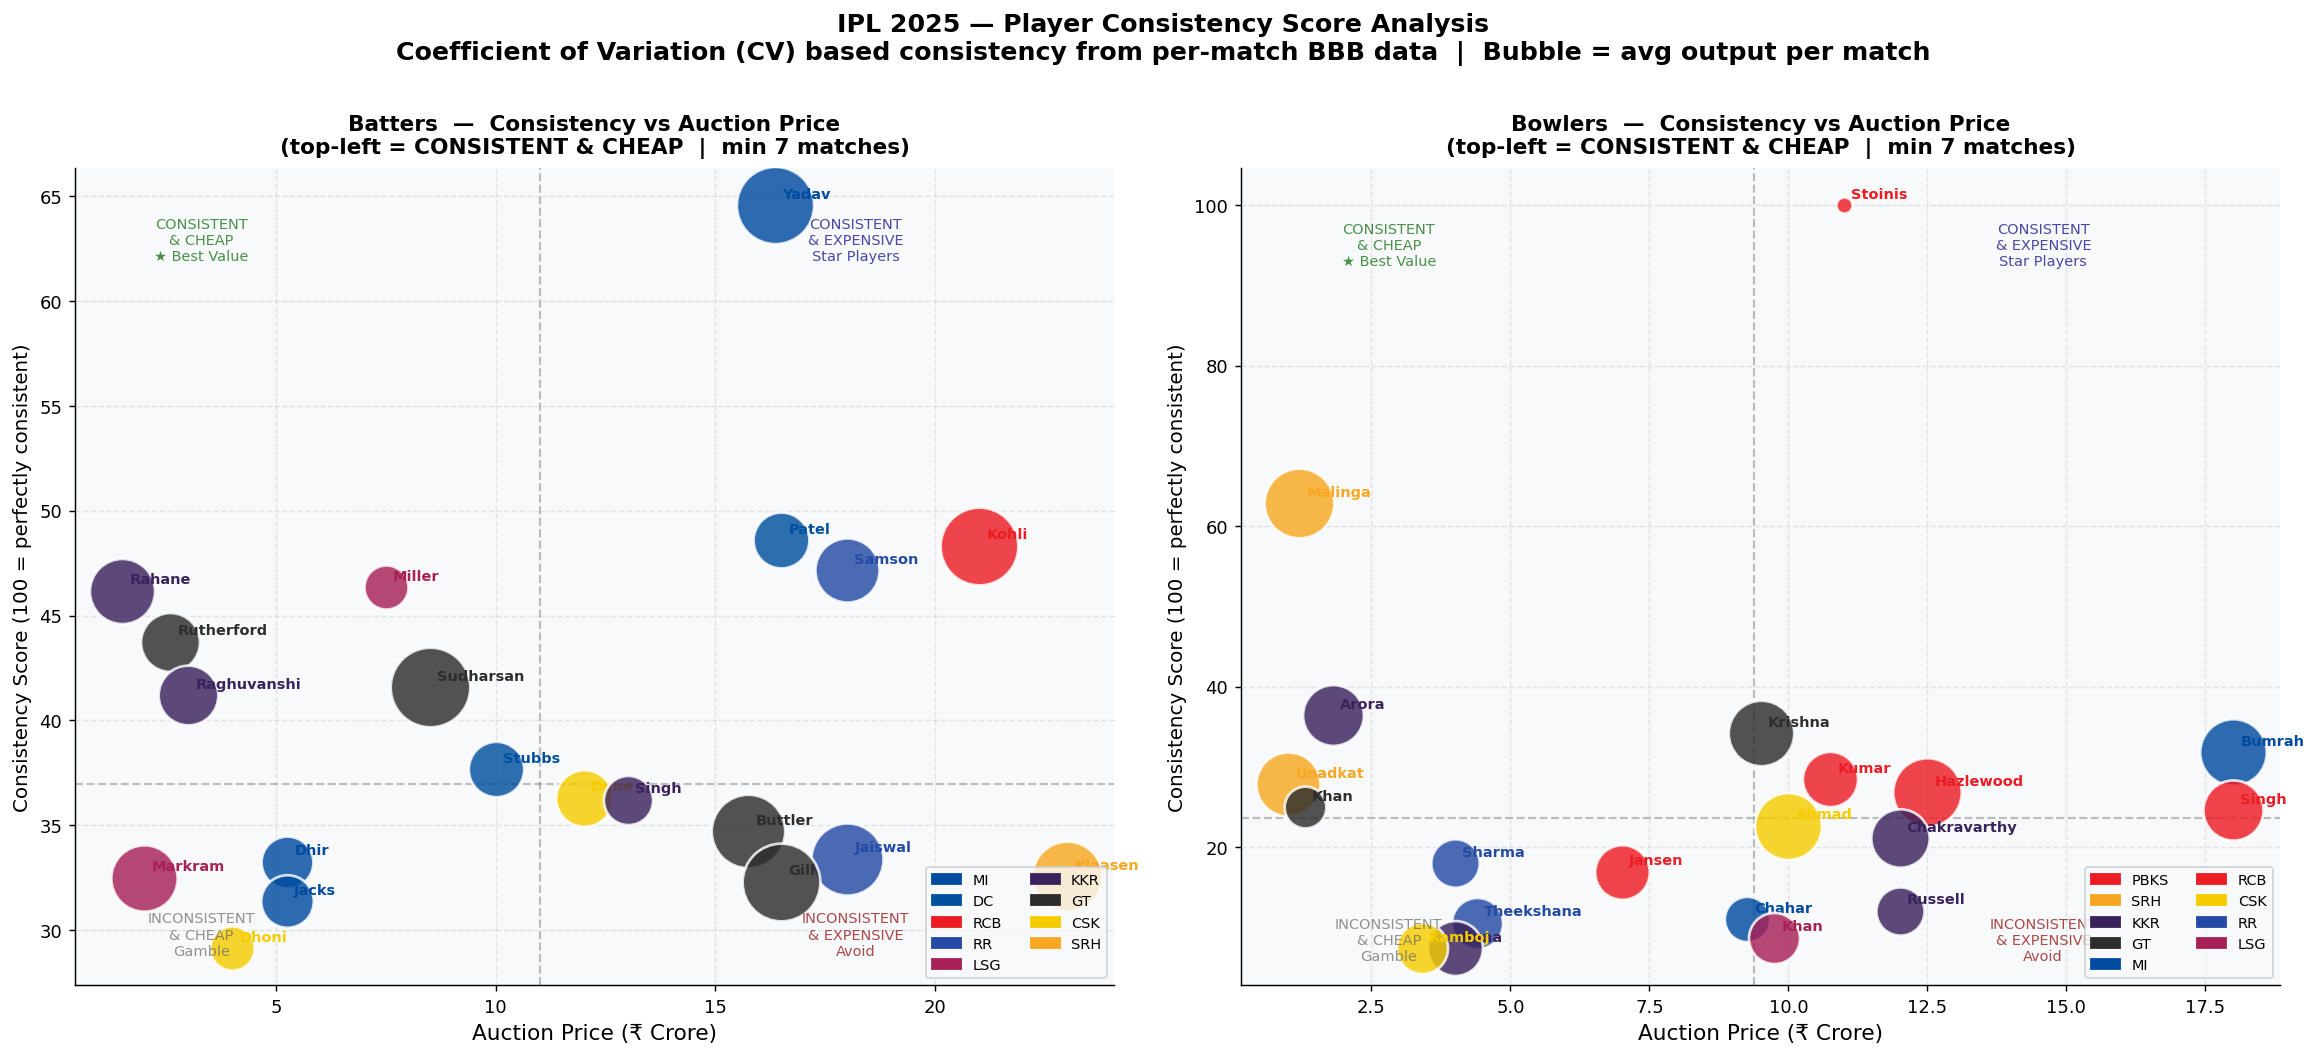

In [83]:
bbb_league = bbb[bbb['match_stage'] == 'League'].copy()
 
batter_match = (
    bbb_league[bbb_league['is_legal'] == 1]
    .groupby(['match_id', 'batter'])['batter_runs']
    .sum()
    .reset_index()
    .rename(columns={'batter': 'Player', 'batter_runs': 'runs'})
)
 
batter_stats = batter_match.groupby('Player').agg(
    matches=('runs', 'count'),
    avg_runs=('runs', 'mean'),
    std_runs=('runs', 'std')
).reset_index()
batter_stats['cv'] = batter_stats['std_runs'] / (batter_stats['avg_runs'] + 1e-9) * 100
batter_stats['consistency'] = 100 - batter_stats['cv'].clip(0, 100)
batter_stats = batter_stats[batter_stats['matches'] >= 7].copy()
 
# Merge with price
bat_price = bat_df[['Player', 'Team', 'Abbr', 'Price_Cr']].copy()
ar_bat_price = ar_df[['Player', 'Team', 'Abbr', 'Price_Cr']].copy()
all_prices = pd.concat([bat_price, ar_bat_price]).drop_duplicates('Player')
 
batter_stats = batter_stats.merge(all_prices, on='Player', how='left').dropna(subset=['Price_Cr'])
batter_stats = batter_stats.sort_values('consistency', ascending=False).head(20)
 
# ── Compute per-match wickets from BBB ───────────────────────
bowler_match = (
    bbb_league[bbb_league['bowler_wicket'] == 1]
    .groupby(['match_id', 'bowler'])['bowler_wicket']
    .sum()
    .reset_index()
    .rename(columns={'bowler': 'Player', 'bowler_wicket': 'wickets'})
)
all_match_ids = bbb_league['match_id'].unique()
all_bowlers = bbb_league[bbb_league['is_legal']==1].groupby(
    ['match_id','bowler'])['is_legal'].count().reset_index()[['match_id','bowler']].rename(
    columns={'bowler':'Player'})
bowler_match_full = all_bowlers.merge(bowler_match, on=['match_id','Player'], how='left').fillna(0)
 
bowler_stats = bowler_match_full.groupby('Player').agg(
    matches=('wickets', 'count'),
    avg_wkts=('wickets', 'mean'),
    std_wkts=('wickets', 'std')
).reset_index()
bowler_stats['cv'] = bowler_stats['std_wkts'] / (bowler_stats['avg_wkts'] + 1e-9) * 100
bowler_stats['consistency'] = 100 - bowler_stats['cv'].clip(0, 100)
bowler_stats = bowler_stats[bowler_stats['matches'] >= 7].copy()
 
bow_price = bow_df[['Player', 'Team', 'Abbr', 'Price_Cr']].copy()
ar_bow_price = ar_df[['Player', 'Team', 'Abbr', 'Price_Cr']].copy()
all_bow_prices = pd.concat([bow_price, ar_bow_price]).drop_duplicates('Player')
 
bowler_stats = bowler_stats.merge(all_bow_prices, on='Player', how='left').dropna(subset=['Price_Cr'])
bowler_stats = bowler_stats.sort_values('consistency', ascending=False).head(20)
 
# ── Plot ─────────────────────────────────────────────────────
def add_quadrant_shading(ax, xmid, ymid, xmax, ymax=105):
    ax.axhspan(ymid, ymax, xmin=0,
               xmax=(xmid - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]),
               alpha=0.04, color='green')
    ax.axhspan(ymid, ymax,
               xmin=(xmid - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]),
               xmax=1, alpha=0.04, color='blue')
    ax.axhspan(0, ymid, xmin=0,
               xmax=(xmid - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]),
               alpha=0.04, color='gray')
    ax.axhspan(0, ymid,
               xmin=(xmid - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]),
               xmax=1, alpha=0.04, color='red')
 
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("IPL 2025 — Player Consistency Score Analysis\n"
             "Coefficient of Variation (CV) based consistency from per-match BBB data  |  "
             "Bubble = avg output per match",
             fontsize=14, fontweight='bold', y=1.01)
 
for ax, df_plot, kind, metric, scale in [
    (axes[0], batter_stats,  "Batters",  "avg_runs", 0.4),
    (axes[1], bowler_stats,  "Bowlers",  "avg_wkts", 8.0),
]:
    xmid = df_plot['Price_Cr'].median()
    ymid = df_plot['consistency'].median()
 
    ax.axvline(xmid, color='gray', linestyle='--', linewidth=1.2, alpha=0.5)
    ax.axhline(ymid, color='gray', linestyle='--', linewidth=1.2, alpha=0.5)
 
    for _, row in df_plot.iterrows():
        abbr = row.get('Abbr', 'NA')
        color = TC.get(abbr, '#888888')
        size  = max(80, row[metric] * scale * 100)
 
        ax.scatter(row['Price_Cr'], row['consistency'],
                   s=size, color=color, alpha=0.82,
                   edgecolors='white', linewidths=1.5, zorder=3)
 
        short = row['Player'].split()[-1]
        ax.annotate(short,
                    xy=(row['Price_Cr'], row['consistency']),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=8, fontweight='bold', color=color)
 
    ax.set_xlabel("Auction Price (₹ Crore)", fontsize=12)
    ax.set_ylabel("Consistency Score (100 = perfectly consistent)", fontsize=11)
    ax.set_title(f"{kind}  —  Consistency vs Auction Price\n"
                 f"(top-left = CONSISTENT & CHEAP  |  min {7} matches)",
                 fontsize=12, pad=8)
 
    # Quadrant labels
    xl, xr = ax.get_xlim()
    yl, yr = ax.get_ylim()
    ax.text(xmid * 0.3, ymid + (yr-ymid)*0.85,
            "CONSISTENT\n& CHEAP\n★ Best Value",
            fontsize=8, color='darkgreen', alpha=0.7, ha='center')
    ax.text(xmid + (xr-xmid)*0.55, ymid + (yr-ymid)*0.85,
            "CONSISTENT\n& EXPENSIVE\nStar Players",
            fontsize=8, color='navy', alpha=0.7, ha='center')
    ax.text(xmid * 0.3, yl + (ymid-yl)*0.15,
            "INCONSISTENT\n& CHEAP\nGamble",
            fontsize=8, color='#666666', alpha=0.7, ha='center')
    ax.text(xmid + (xr-xmid)*0.55, yl + (ymid-yl)*0.15,
            "INCONSISTENT\n& EXPENSIVE\nAvoid",
            fontsize=8, color='darkred', alpha=0.7, ha='center')
 
    # Team legend patches
    legend_teams = df_plot[['Abbr']].dropna().drop_duplicates()['Abbr'].tolist()
    patches = [mpatches.Patch(color=TC.get(t,'gray'), label=t) for t in legend_teams if t in TC]
    ax.legend(handles=patches, fontsize=8, ncol=2,
              loc='lower right', framealpha=0.8)
 
plt.tight_layout()
plt.show()

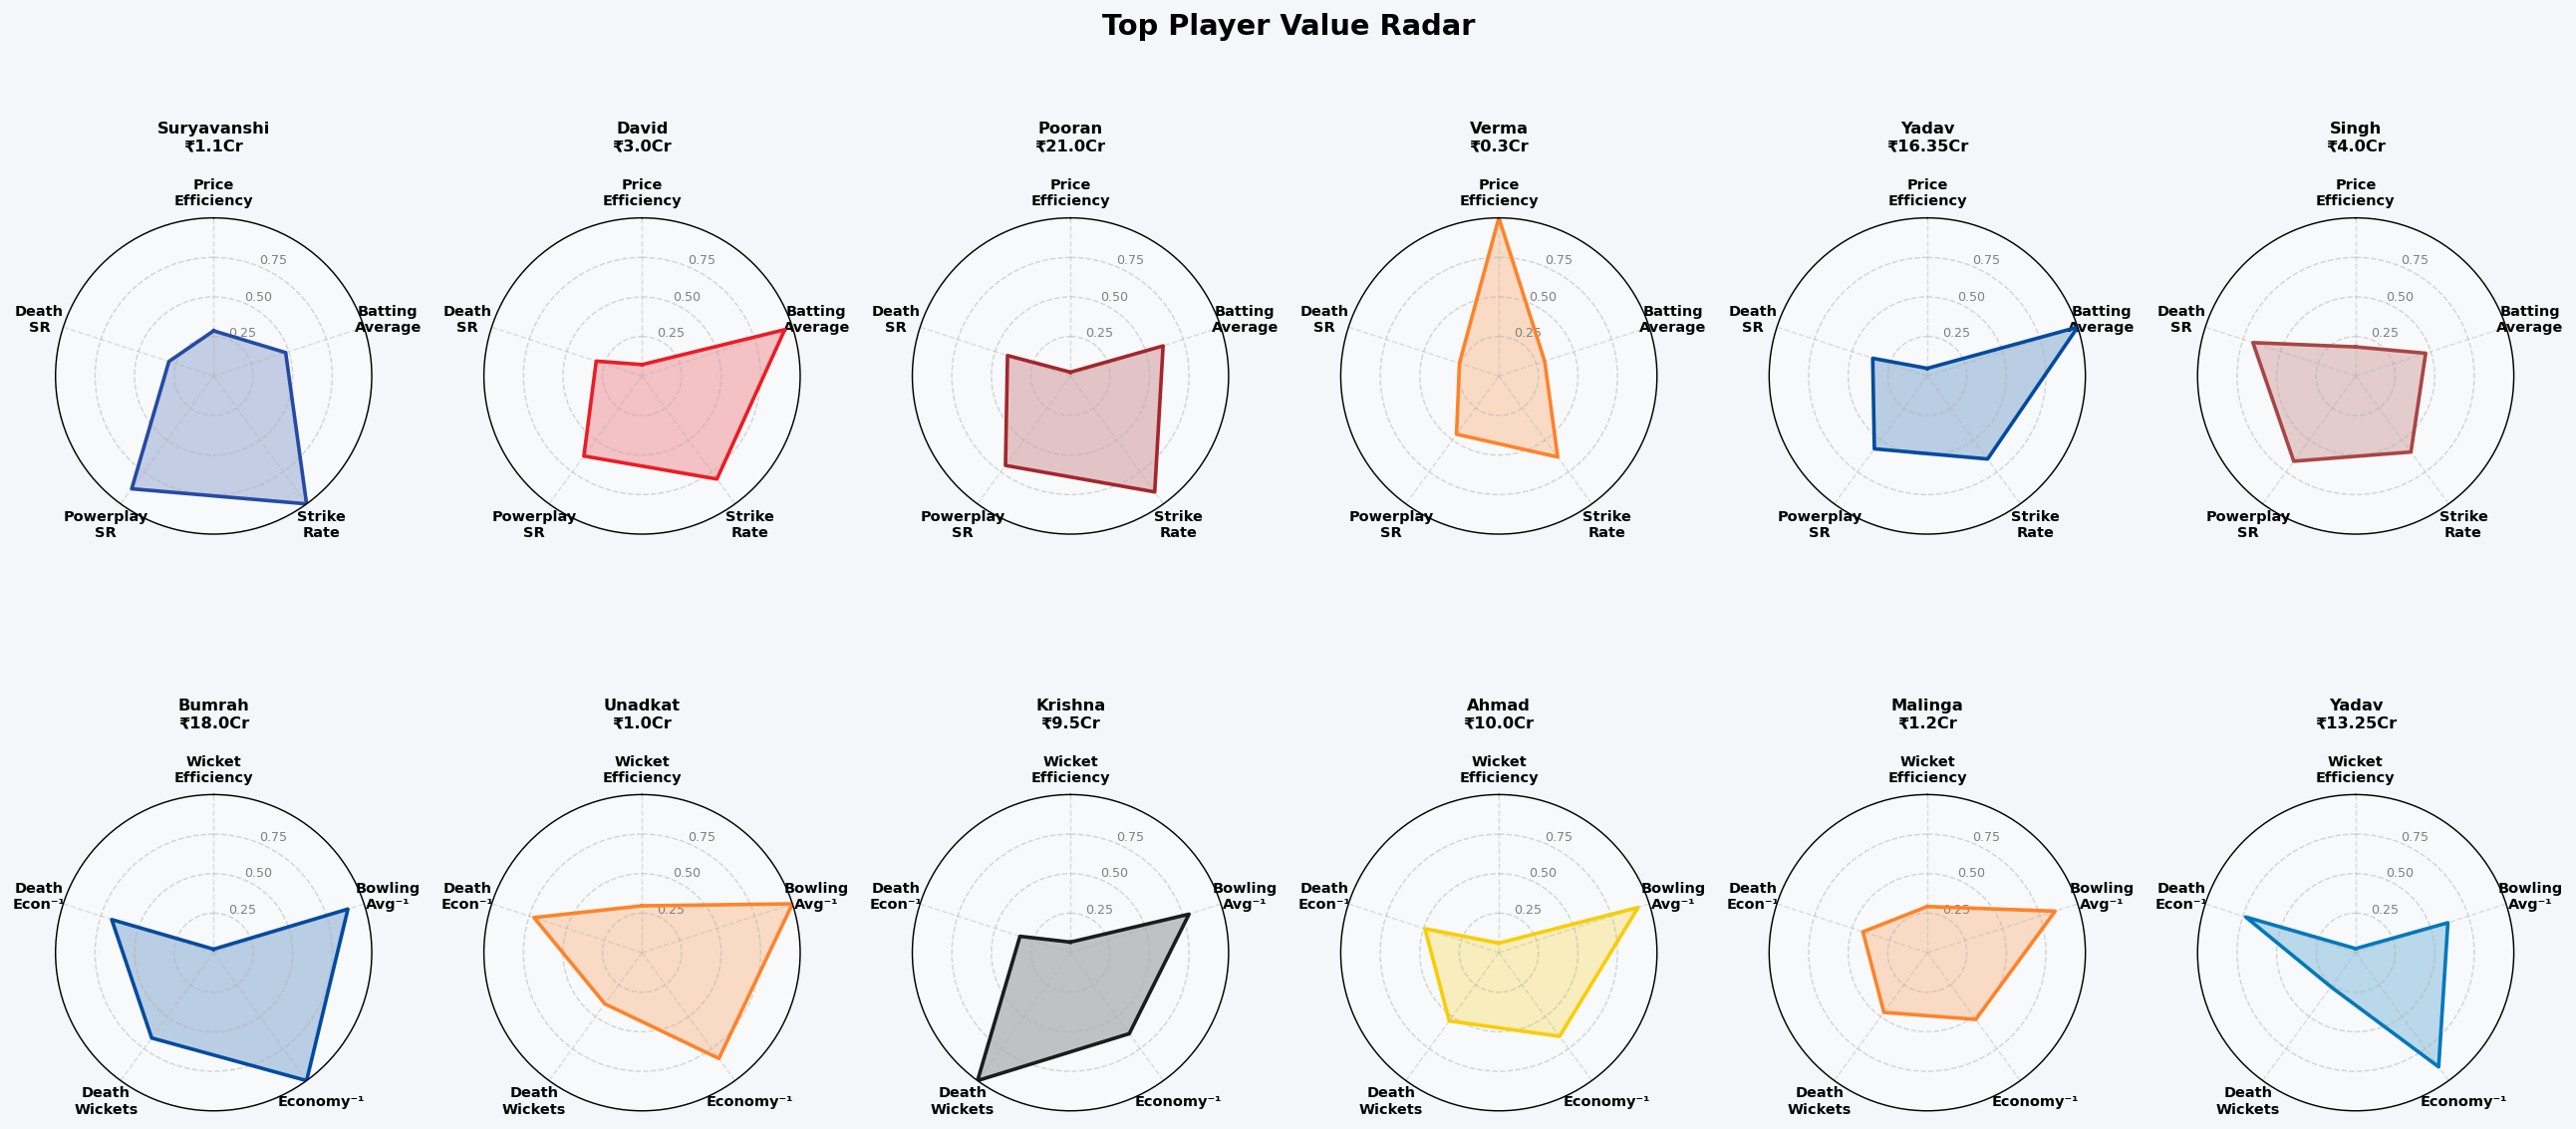

In [111]:
fig = plt.figure(figsize=(20, 10), facecolor="#F4F6FA")

# Top 6 batters
top_bat = bat_scored.nlargest(6, "value_score")

for i, (_, row) in enumerate(top_bat.iterrows()):
    ax = fig.add_subplot(2, 6, i+1, polar=True)
    vals = [row[d] for d in BAT_DIMS]
    color = TEAM_COLORS.get(row["Abbr"], "#555")
    label = f"{row['Player'].split()[-1]}\n₹{row['Price_Cr']}Cr"
    radar_chart(ax, vals, BAT_LABELS, color, label)

# Top 6 bowlers
top_bowl = bowl_scored.nlargest(6, "value_score")

for i, (_, row) in enumerate(top_bowl.iterrows()):
    ax = fig.add_subplot(2, 6, 6+i+1, polar=True)
    vals = [row[d] for d in BOWL_DIMS]
    color = TEAM_COLORS.get(row["Abbr"], "#555")
    label = f"{row['Player'].split()[-1]}\n₹{row['Price_Cr']}Cr"
    radar_chart(ax, vals, BOWL_LABELS, color, label)

plt.suptitle("Top Player Value Radar", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

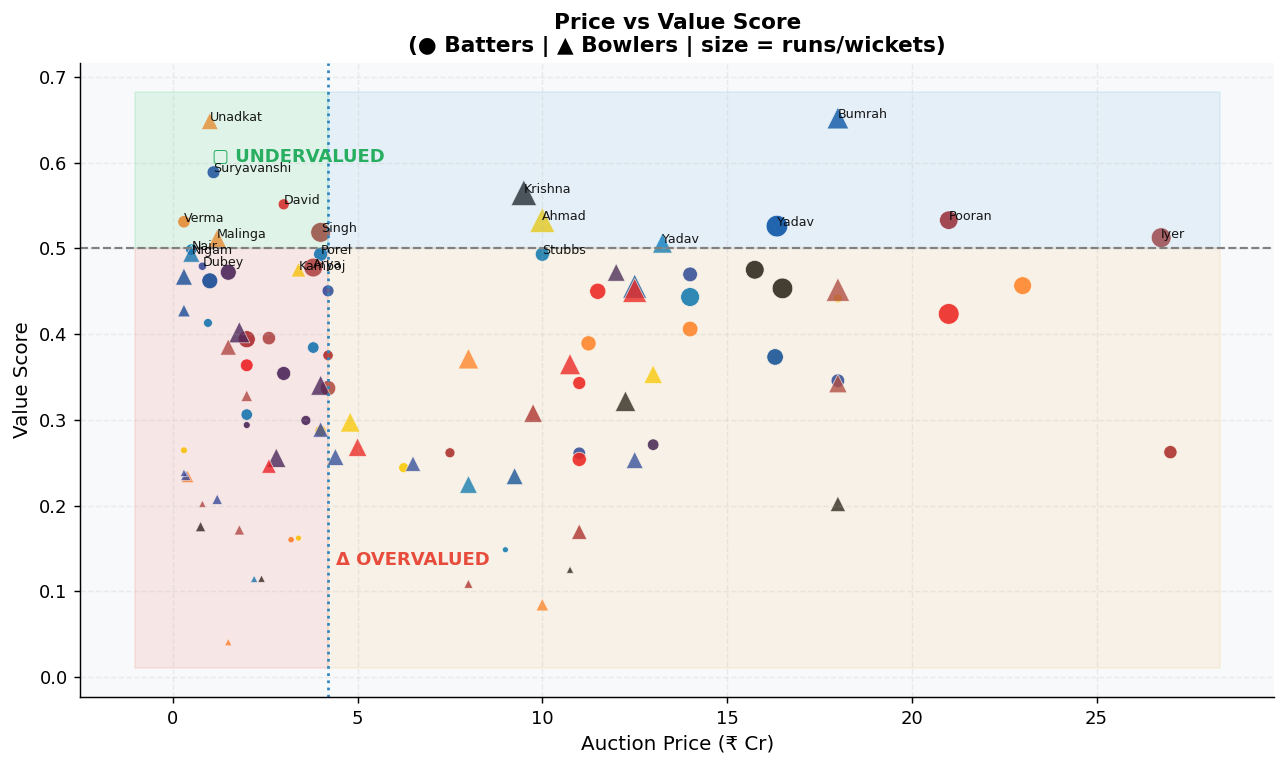

In [117]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# --- Scatter points ---
plt.scatter(
    bat_scored["Price_Cr"], bat_scored["value_score"],
    c=[TEAM_COLORS.get(t,"#888") for t in bat_scored["Abbr"]],
    s=bat_scored["RUNS"]/5, alpha=0.9, edgecolors="white", linewidth=0.4
)

plt.scatter(
    bowl_scored["Price_Cr"], bowl_scored["value_score"],
    c=[TEAM_COLORS.get(t,"#888") for t in bowl_scored["Abbr"]],
    s=bowl_scored["WKTS"]*8, alpha=0.8, marker="^",
    edgecolors="white", linewidth=0.4
)

# --- Median lines ---
median_price = bat_scored["Price_Cr"].median()
median_value = 0.5

plt.axvline(median_price, linestyle=":", color="#2E86C1", linewidth=1.5)
plt.axhline(median_value, linestyle="--", color="gray", linewidth=1.2)

# --- Axis limits ---
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

# --- Quadrant shading (match your image style) ---
plt.fill_betweenx([median_value, ymax], xmin, median_price,
                  color="#2ecc71", alpha=0.12)   # top-left (GEMS)

plt.fill_betweenx([median_value, ymax], median_price, xmax,
                  color="#5dade2", alpha=0.12)   # top-right

plt.fill_betweenx([ymin, median_value], xmin, median_price,
                  color="#e74c3c", alpha=0.10)   # bottom-left

plt.fill_betweenx([ymin, median_value], median_price, xmax,
                  color="#f5b041", alpha=0.10)   # bottom-right (OVERVALUED)

# --- Labels (exact style) ---
plt.text(median_price*0.25, ymax*0.88, "▢ UNDERVALUED",
         color="#27ae60", fontsize=10, fontweight="bold")

plt.text(median_price*1.05, ymax*0.88, "",
         color="#2980b9", fontsize=10)

plt.text(median_price*1.05, ymin+0.12, "Δ OVERVALUED",
         color="#e74c3c", fontsize=10, fontweight="bold")

# --- Player annotations (like your plot) ---
for _, row in bat_scored.nlargest(12, "value_score").iterrows():
    plt.annotate(
        row["Player"].split()[-1],
        (row["Price_Cr"], row["value_score"]),
        fontsize=7, alpha=0.9
    )

for _, row in bowl_scored.nlargest(8, "value_score").iterrows():
    plt.annotate(
        row["Player"].split()[-1],
        (row["Price_Cr"], row["value_score"]),
        fontsize=7, alpha=0.9
    )

# --- Title & labels ---
plt.title("Price vs Value Score\n(● Batters | ▲ Bowlers | size = runs/wickets)",
          fontsize=12, fontweight="bold")

plt.xlabel("Auction Price (₹ Cr)")
plt.ylabel("Value Score")

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

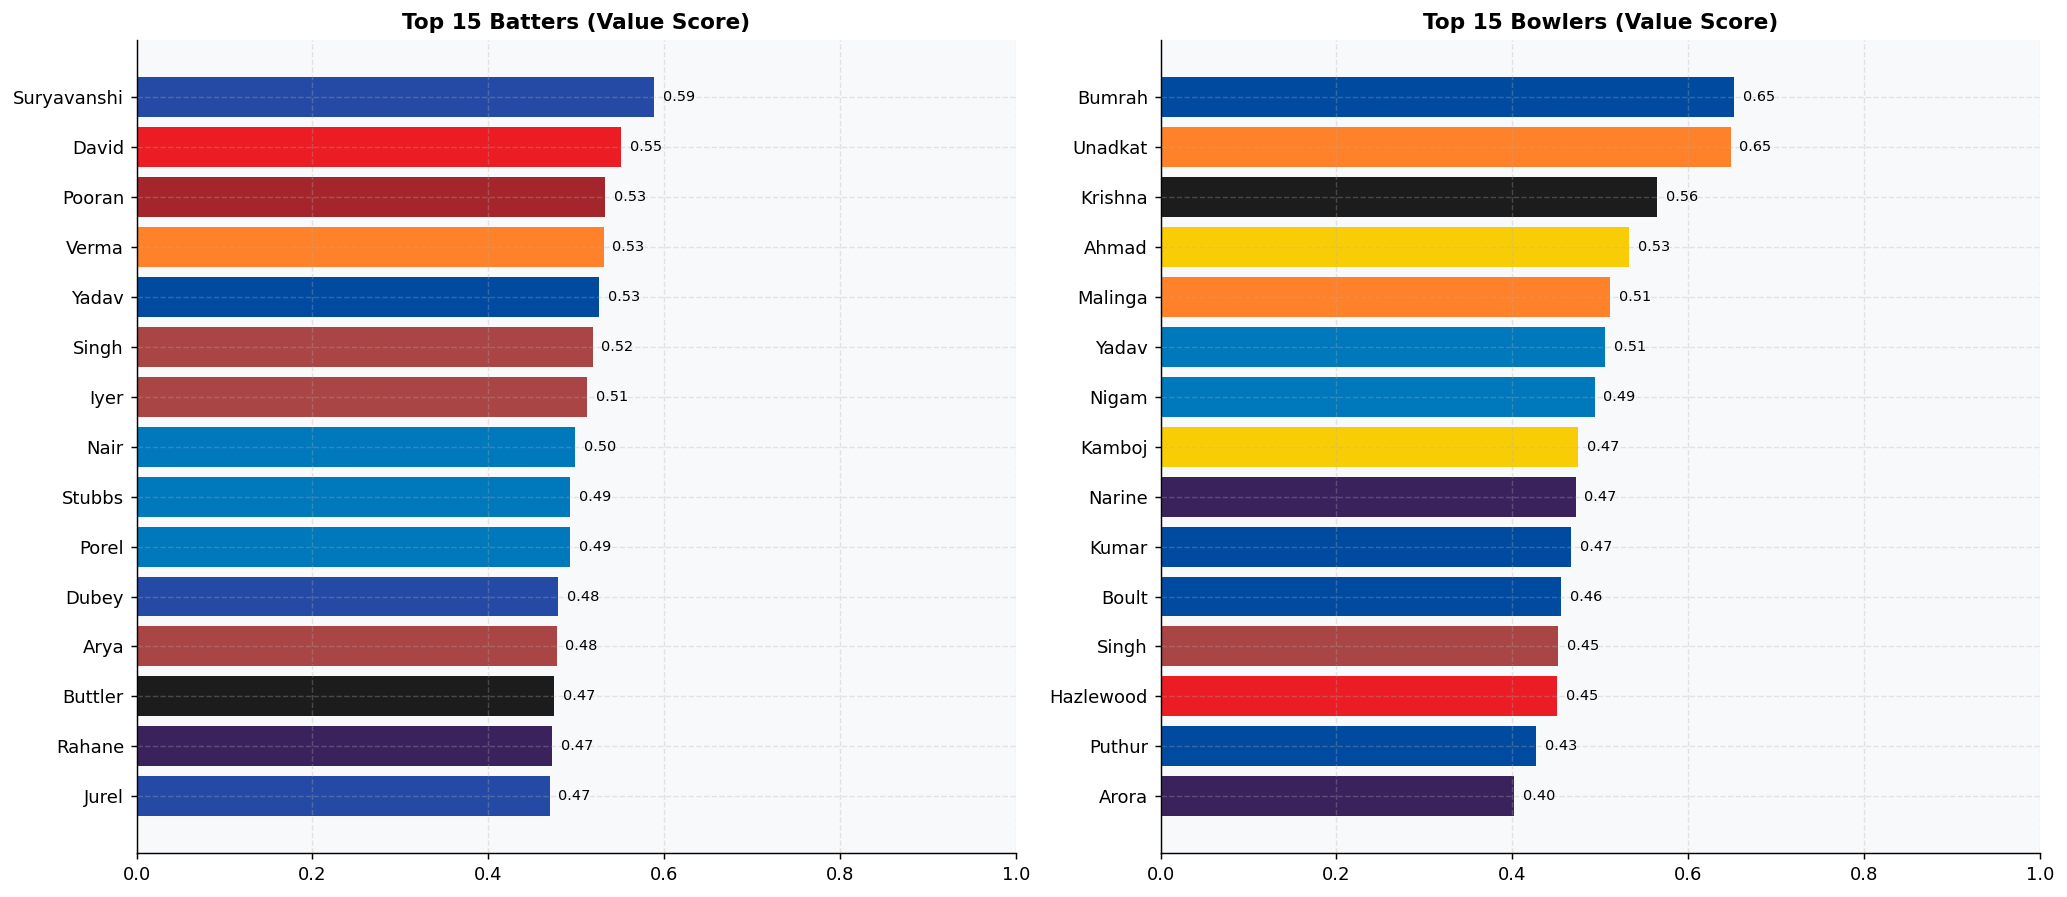

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

# ---- Batters ----
top25_bat = bat_scored.nlargest(15, "value_score").iloc[::-1]

bars = axes[0].barh(
    top25_bat["Player"].apply(lambda x: x.split()[-1]),
    top25_bat["value_score"],
    color=[TEAM_COLORS.get(t,"#888") for t in top25_bat["Abbr"]]
)

for bar, val in zip(bars, top25_bat["value_score"]):
    axes[0].text(val+0.01, bar.get_y()+bar.get_height()/2,
                 f"{val:.2f}", va="center", fontsize=8)

axes[0].set_title("Top 15 Batters (Value Score)")
axes[0].set_xlim(0,1)

# ---- Bowlers ----
top25_bowl = bowl_scored.nlargest(15, "value_score").iloc[::-1]

bars = axes[1].barh(
    top25_bowl["Player"].apply(lambda x: x.split()[-1]),
    top25_bowl["value_score"],
    color=[TEAM_COLORS.get(t,"#888") for t in top25_bowl["Abbr"]]
)

for bar, val in zip(bars, top25_bowl["value_score"]):
    axes[1].text(val+0.01, bar.get_y()+bar.get_height()/2,
                 f"{val:.2f}", va="center", fontsize=8)

axes[1].set_title("Top 15 Bowlers (Value Score)")
axes[1].set_xlim(0,1)

plt.tight_layout()
plt.show()

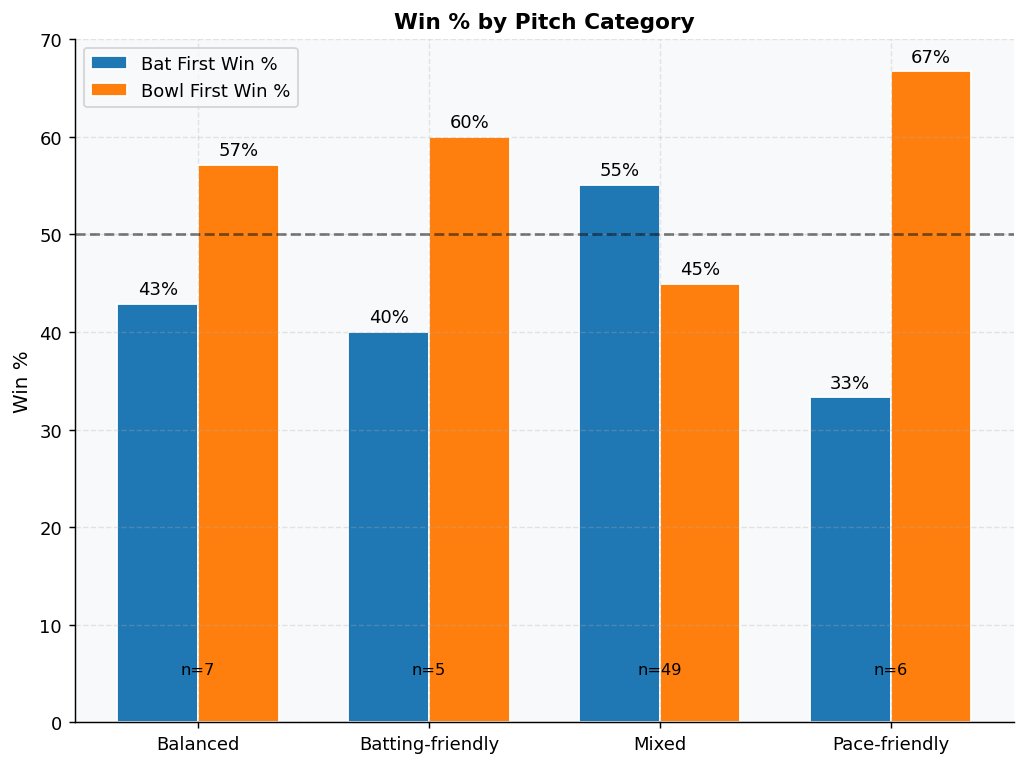

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
mat_v = pd.read_csv("cleaned_matches.csv", usecols=range(31))
mat_v = mat_v[mat_v["no_result"] == 0].copy()

# Identify batting first team
mat_v["bat_first_team"] = mat_v.apply(
    lambda r: r["toss_winner"] if r["toss_decision"]=="bat"
              else (r["team2"] if r["toss_winner"]==r["team1"] else r["team1"]),
    axis=1
)

# Did batting first team win?
mat_v["bat_first_won"] = (mat_v["bat_first_team"] == mat_v["winner"]).astype(int)

# Aggregate
g = (mat_v.groupby(["pitch_category"])
          .agg(matches=("bat_first_won","count"),
               bat_wins=("bat_first_won","sum"))
          .reset_index())

g["bat_first_win_pct"]  = (g["bat_wins"]/g["matches"]*100).round(1)
g["bowl_first_win_pct"] = (100 - g["bat_first_win_pct"]).round(1)

# Plot
plt.figure(figsize=(8,6))

x_pos = np.arange(len(g))
w = 0.35

bars1 = plt.bar(x_pos - w/2, g["bat_first_win_pct"],
                width=w, label="Bat First Win %",
                edgecolor="white")

bars2 = plt.bar(x_pos + w/2, g["bowl_first_win_pct"],
                width=w, label="Bowl First Win %",
                edgecolor="white")

# Labels
for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f"{bar.get_height():.0f}%",
             ha='center', fontsize=10)

plt.axhline(50, linestyle="--", color="black", alpha=0.5)

plt.xticks(x_pos, g["pitch_category"])
plt.ylabel("Win %")
plt.title("Win % by Pitch Category")
plt.legend()

# sample size
for i, row in enumerate(g.itertuples()):
    plt.text(i, 5, f"n={row.matches}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

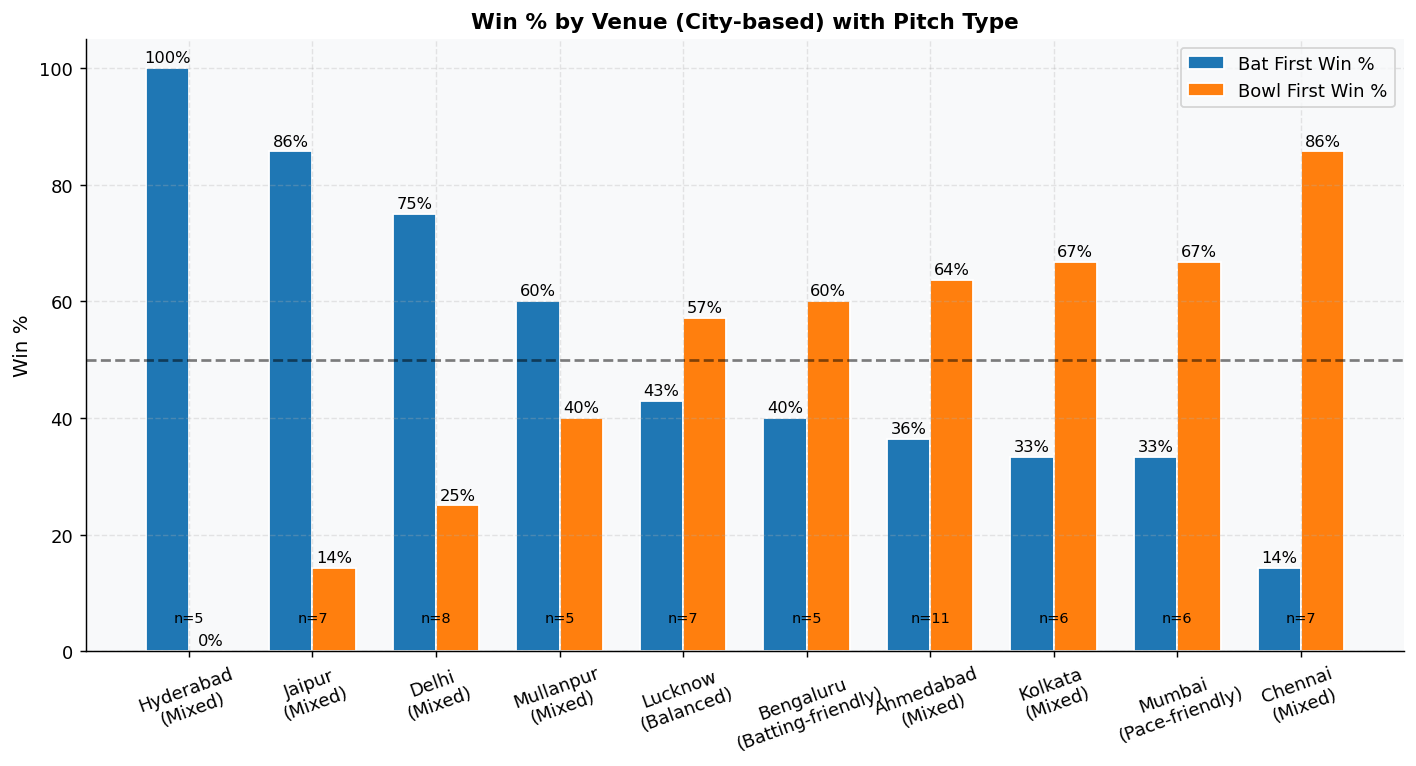

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load & clean data
# -----------------------------
mat_v = pd.read_csv("cleaned_matches.csv", usecols=range(31))
mat_v = mat_v[mat_v["no_result"] == 0].copy()

# -----------------------------
# Identify batting first team
# -----------------------------
mat_v["bat_first_team"] = mat_v.apply(
    lambda r: r["toss_winner"] if r["toss_decision"]=="bat"
    else (r["team2"] if r["toss_winner"]==r["team1"] else r["team1"]),
    axis=1
)

mat_v["bat_first_won"] = (mat_v["bat_first_team"] == mat_v["winner"]).astype(int)

# -----------------------------
# Venue-level stats
# -----------------------------
venue_stats = (mat_v.groupby("venue")
                      .agg(matches=("bat_first_won","count"),
                           bat_wins=("bat_first_won","sum"))
                      .reset_index())

venue_stats["bat_first_win_pct"]  = (venue_stats["bat_wins"] / venue_stats["matches"] * 100).round(1)
venue_stats["bowl_first_win_pct"] = (100 - venue_stats["bat_first_win_pct"]).round(1)

# -----------------------------
# Get dominant pitch type per venue
# -----------------------------
pitch_map = (mat_v.groupby(["venue","pitch_category"])
                    .size()
                    .reset_index(name="count"))

pitch_map = pitch_map.sort_values(["venue","count"], ascending=[True,False])
pitch_map = pitch_map.drop_duplicates("venue")

venue_stats = venue_stats.merge(
    pitch_map[["venue","pitch_category"]],
    on="venue", how="left"
)

# -----------------------------
# Extract city names (short labels)
# -----------------------------
venue_stats["city"] = venue_stats["venue"].apply(
    lambda x: x.split(",")[-1].strip() if "," in x else x
)

# Final label: City + Pitch type
venue_stats["label"] = (
    venue_stats["city"] + "\n(" + venue_stats["pitch_category"] + ")"
)

# Sort for visualization
venue_stats = venue_stats.sort_values("bat_first_win_pct", ascending=False)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(11,6))

x_pos = np.arange(len(venue_stats))
w = 0.35

bars1 = plt.bar(x_pos - w/2, venue_stats["bat_first_win_pct"],
                width=w, label="Bat First Win %",
                edgecolor="white")

bars2 = plt.bar(x_pos + w/2, venue_stats["bowl_first_win_pct"],
                width=w, label="Bowl First Win %",
                edgecolor="white")

# Value labels
for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{bar.get_height():.0f}%",
             ha='center', fontsize=9)

# 50% reference line
plt.axhline(50, linestyle="--", color="black", alpha=0.5)

# X-axis labels
plt.xticks(x_pos, venue_stats["label"], rotation=20)

plt.ylabel("Win %")
plt.title("Win % by Venue (City-based) with Pitch Type")
plt.legend()

# Sample size annotation
for i, row in enumerate(venue_stats.itertuples()):
    plt.text(i, 5, f"n={row.matches}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [102]:
# NEW CELL — Top 15 Batters & Bowlers by Composite Score
# (Uses 5 metrics: Price Efficiency, Avg/SR, Phase-specific output)

import pandas as pd, numpy as np, plotly.graph_objects as go
from plotly.subplots import make_subplots

TC_NEW = {"MI":"#004BA0","CSK":"#F9CD05","RCB":"#EC1C24","KKR":"#3A225D",
          "SRH":"#FF822A","RR":"#254AA5","GT":"#444444","LSG":"#A4262C",
          "DC":"#0078BC","PBKS":"#AA4545"}
TM_NEW = {"Mumbai Indians":"MI","Chennai Super Kings":"CSK",
          "Royal Challengers Bengaluru":"RCB","Kolkata Knight Riders":"KKR",
          "Sunrisers Hyderabad":"SRH","Rajasthan Royals":"RR",
          "Gujarat Titans":"GT","Lucknow Super Giants":"LSG",
          "Delhi Capitals":"DC","Punjab Kings":"PBKS"}

# Rebuild phase metrics
pp_b = bbb[bbb["phase"]=="Powerplay"].groupby("batter").agg(
    pp_r=("batter_runs","sum"),pp_bl=("is_legal","sum")).reset_index()
pp_b["pp_sr"] = (pp_b["pp_r"]/pp_b["pp_bl"].replace(0,np.nan)*100).round(1)
dt_b = bbb[bbb["phase"]=="Death"].groupby("batter").agg(
    dt_r=("batter_runs","sum"),dt_bl=("is_legal","sum")).reset_index()
dt_b["dt_sr"] = (dt_b["dt_r"]/dt_b["dt_bl"].replace(0,np.nan)*100).round(1)
dt_bw = bbb[bbb["phase"]=="Death"].groupby("bowler").agg(
    dt_wk=("bowler_wicket","sum"),dt_bl=("is_legal","sum"),
    dt_ru=("total_runs","sum")).reset_index()
dt_bw["dt_econ"] = (dt_bw["dt_ru"]/dt_bw["dt_bl"].replace(0,np.nan)*6).round(2)
pp_bw = bbb[bbb["phase"]=="Powerplay"].groupby("bowler").agg(
    pp_wk=("bowler_wicket","sum"),pp_bl=("is_legal","sum"),
    pp_ru=("total_runs","sum")).reset_index()
pp_bw["pp_econ"] = (pp_bw["pp_ru"]/pp_bw["pp_bl"].replace(0,np.nan)*6).round(2)

# Batters
ab = pd.concat([
    bat[["Player","Team","RUNS","Price_Cr","AVG","SR","INN"]],
    ar[["Player","Team","RUNS","Price_Cr","Bat_AVG","Bat_SR","Bat_INN"]].rename(
       columns={"Bat_AVG":"AVG","Bat_SR":"SR","Bat_INN":"INN"})
], ignore_index=True)
ab["Abbr"] = ab["Team"].map(TM_NEW).fillna(ab["Team"])
ab = ab[ab["INN"]>=4].dropna(subset=["Price_Cr","RUNS","AVG","SR"])
ab = ab.merge(pp_b.rename(columns={"batter":"Player"}), on="Player", how="left")
ab = ab.merge(dt_b.rename(columns={"batter":"Player"}), on="Player", how="left")
ab["price_eff"] = ab["RUNS"]/ab["Price_Cr"]
DIMS_B = {"price_eff":0.25,"AVG":0.20,"SR":0.20,"pp_sr":0.175,"dt_sr":0.175}
for c in DIMS_B:
    ab[c] = ab[c].fillna(ab[c].median())
    mn,mx = ab[c].min(), ab[c].max()
    ab[f"{c}_s"] = (ab[c]-mn)/(mx-mn+1e-9)
ab["score"] = sum(ab[f"{c}_s"]*w for c,w in DIMS_B.items())
ab["fmt_name"] = ab["Player"].apply(lambda x: f"{x.split()[0][0]}.{x.split()[-1]}")

# Bowlers
bw = bowl[["Player","Team","WKTS","Price_Cr","AVG","ECON","SR","INN"]].copy()
bw["Abbr"] = bw["Team"].map(TM_NEW).fillna(bw["Team"])
bw = bw[bw["INN"]>=4].dropna(subset=["Price_Cr","WKTS","AVG","ECON"])
bw = bw.merge(dt_bw.rename(columns={"bowler":"Player"}), on="Player", how="left")
bw = bw.merge(pp_bw.rename(columns={"bowler":"Player"}), on="Player", how="left")
bw["wkt_per_cr"]  = bw["WKTS"]/bw["Price_Cr"]
bw["avg_inv"]     = 1/bw["AVG"].replace(0,np.nan)
bw["econ_inv"]    = 1/bw["ECON"].replace(0,np.nan)
bw["pp_econ_inv"] = 1/bw["pp_econ"].replace(0,np.nan)
bw["dt_econ_inv"] = 1/bw["dt_econ"].replace(0,np.nan)
DIMS_W = {"wkt_per_cr":0.25,"avg_inv":0.20,"econ_inv":0.20,"pp_econ_inv":0.175,"dt_econ_inv":0.175}
for c in DIMS_W:
    bw[c] = bw[c].fillna(bw[c].median() if bw[c].notna().any() else 0)
    mn,mx = bw[c].min(), bw[c].max()
    bw[f"{c}_s"] = (bw[c]-mn)/(mx-mn+1e-9)
bw["score"] = sum(bw[f"{c}_s"]*w for c,w in DIMS_W.items())
bw["fmt_name"] = bw["Player"].apply(lambda x: f"{x.split()[0][0]}.{x.split()[-1]}")

top15b  = ab.nlargest(15,"score").iloc[::-1]
top15bw = bw.nlargest(15,"score").iloc[::-1]

fig = make_subplots(rows=1, cols=2,
    subplot_titles=(
        "Top 15 Batters — Composite Value Score<br>"
        "<sup>Price Efficiency 25% | Avg 20% | SR 20% | PP-SR 17.5% | Death-SR 17.5%</sup>",
        "Top 15 Bowlers — Composite Value Score<br>"
        "<sup>Wkts/Cr 25% | Avg⁻¹ 20% | Econ⁻¹ 20% | PP-Econ⁻¹ 17.5% | Death-Econ⁻¹ 17.5%</sup>"
    ),
    horizontal_spacing=0.15)

for col, df, key_col, key_label, extra_cols, extra_labels in [
    (1, top15b,  "RUNS", "Runs",  ["AVG","SR","Price_Cr"],  ["Avg","SR","Price"]),
    (2, top15bw, "WKTS", "Wkts", ["AVG","ECON","Price_Cr"], ["Avg","Econ","Price"]),
]:
    colors = [TC_NEW.get(t,"#888") for t in df["Abbr"]]
    fig.add_trace(go.Bar(
        x=df["score"], y=df["fmt_name"],
        orientation="h",
        marker=dict(color=colors, line=dict(width=0.5, color="white")),
        text=df.apply(lambda r:
            f"Score:{r['score']:.2f} | {key_label}:{int(r[key_col])} | "
            f"₹{r['Price_Cr']}Cr", axis=1),
        textposition="outside",
        textfont=dict(size=8),
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Team: %{customdata[1]}<br>"
            f"Price: ₹%{{customdata[2]}}Cr<br>"
            f"{key_label}: %{{customdata[3]}}<br>"
            f"{extra_labels[0]}: %{{customdata[4]}}<br>"
            f"{extra_labels[1]}: %{{customdata[5]}}<br>"
            "Composite Score: %{x:.3f}<extra></extra>"
        ),
        customdata=df[["Player","Abbr","Price_Cr",key_col]+extra_cols[:2]].round(2).values,
        showlegend=False
    ), row=1, col=col)
    fig.update_xaxes(title_text="Composite Value Score (0–1)", range=[0,1.05], row=1, col=col)
    fig.add_vline(x=0.5, line_dash="dot", line_color="gray", opacity=0.5, row=1, col=col)

# Team legend
for team, color in TC_NEW.items():
    fig.add_trace(go.Bar(x=[None], y=[None], name=team,
                         marker_color=color, showlegend=True))

fig.update_layout(
    title=dict(
        text="<b>IPL 2025 — Top 15 Batters & Bowlers by Composite Value Score</b><br>"
             "<sup>Multi-metric ranking combining price efficiency, overall stats, "
             "and phase-specific performance</sup>",
        x=0.5, xanchor="center", font=dict(size=15)
    ),
    height=620, width=1350,
    paper_bgcolor="white", plot_bgcolor="#FAFAFA",
    legend=dict(title="Team", orientation="h", x=0.5, xanchor="center",
                y=-0.12, bgcolor="rgba(255,255,255,0.9)"),
    font=dict(family="Arial", size=11)
)
fig.show()